# Aula 01 - Projeto RH

# 0. Importar bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
import time

# 1. Entendimento do Negócio

A RetaiX emprega cerca de 4000 funcionários. No entanto, todos os anos, cerca de 15% de seus funcionários deixam a empresa e precisam ser substituídos por novos funcionários que estão disponíveis no mercado. A gestão acredita que esse nível de rotatividade (funcionários saindo, seja por vontade própria ou porque foram demitidos) é ruim para a empresa, pelos seguintes motivos:

Dificuldade no cumprimento dos prazos, resultando em perda de reputação entre consumidores e parceiros.
Um departamento considerável precisa ser mantido para fins de recrutamento de novos talentos.
Na maioria das vezes, os novos funcionários precisam ser treinados para o trabalho e/ou precisam de tempo para se ambientarem à empresa.
Por outro lado, a RetailX também percebeu que poderia melhorar o relacionamento com os clientes, por meio do entendimento do comportamento de compra deles. A empresa possui dados de campanhas, compras, cadastro e até da renda de cada cliente.

Diante deste cenário a empresa decidiu investir em dois projetos:
* Projeto de RH;
* Projeto de CRM.

Neste momento, focaremos no Projeto de RH. A seguir estão dispostas as demandas:
* Análise dos dados para entender padrões de comportamentos dos funcionários (obter personas);
* Análise dos dados para entender as variáveis que mais influenciam na alta rotatividade dos funcionários;
* Obter a probabilidade de um funcionário sair da empresa e com isso as variáveis que mais impactam o aumento da probabilidade de saída;
* Gerar um relatório com as conclusões para que o gestor do RH possa tomar as devidas providências para que a rotatividade seja reduzida.

# 2. Entendimento dos Dados

### 2.1 Leitura da Base de Funcionários

In [3]:
df_funcionarios = pd.read_csv("../data/raw/tb_rh_funcionarios.csv", engine="pyarrow")
df_funcionarios.head()

,Idade,Rotatividade,ViagensDeNegocio,Departamento,DistanciaDeCasa,Educacao,CampoDeEducacao,ContagemDeEmpregados,IDDoEmpregado,Genero,...,NumeroDeEmpresas,MaiorDe18,AumentoPercentualSalario,HorasPadrao,NivelDeOpcaoDeCompraDeAcoes,TotalDeAnosTrabalhados,TreinamentosNoUltimoAno,AnosNaEmpresa,AnosDesdeUltimaPromocao,AnosComAtualGestor
0,51,Nao,Viagens_Raras,Vendas,6,2,Ciências da Vida,1,1,Feminino,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Sim,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,10,1,Ciências da Vida,1,2,Feminino,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,Nao,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,17,4,Outro,1,3,Masculino,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,Nao,Nao_Viaja,Pesquisa_e_Desenvolvimento,2,5,Ciências da Vida,1,4,Masculino,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,10,1,Médica,1,5,Masculino,...,4.0,Y,12,8,2,9.0,2,6,0,4


### 2.2 Leitura da Base de Pesquisa dos Funcionários

In [4]:
df_pesquisa_funcionarios = pd.read_csv("../data/raw/tb_rh_pesquisa_funcionarios.csv", engine="pyarrow")
df_pesquisa_funcionarios.head()

,IDDoEmpregado,SatisfacaoComAmbiente,SatisfacaoNoTrabalho,EquilibrioTrabalhoVida
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0


### 2.3 Leitura da Base de Pesquisa dos Gestores

In [5]:
df_pesquisa_gestores = pd.read_csv("../data/raw/tb_rh_pesquisa_gestores.csv", engine="pyarrow")
df_pesquisa_gestores.head()

,IDDoEmpregado,EnvolvimentoNoTrabalho,AvaliacaoDeDesempenho
0,1,3,3
1,2,2,4
2,3,3,3
3,4,2,3
4,5,3,3


## 2.4 Join entre tabelas

In [6]:
df_aux1 = pd.merge(df_funcionarios, df_pesquisa_funcionarios, on='IDDoEmpregado', how='left')
df_publico = pd.merge(df_aux1, df_pesquisa_gestores, on='IDDoEmpregado', how='left')
df_publico.head()

,Idade,Rotatividade,ViagensDeNegocio,Departamento,DistanciaDeCasa,Educacao,CampoDeEducacao,ContagemDeEmpregados,IDDoEmpregado,Genero,...,TotalDeAnosTrabalhados,TreinamentosNoUltimoAno,AnosNaEmpresa,AnosDesdeUltimaPromocao,AnosComAtualGestor,SatisfacaoComAmbiente,SatisfacaoNoTrabalho,EquilibrioTrabalhoVida,EnvolvimentoNoTrabalho,AvaliacaoDeDesempenho
0,51,Nao,Viagens_Raras,Vendas,6,2,Ciências da Vida,1,1,Feminino,...,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,31,Sim,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,10,1,Ciências da Vida,1,2,Feminino,...,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,32,Nao,Viagens_Frequentes,Pesquisa_e_Desenvolvimento,17,4,Outro,1,3,Masculino,...,5.0,2,5,0,3,2.0,2.0,1.0,3,3
3,38,Nao,Nao_Viaja,Pesquisa_e_Desenvolvimento,2,5,Ciências da Vida,1,4,Masculino,...,13.0,5,8,7,5,4.0,4.0,3.0,2,3
4,32,Nao,Viagens_Raras,Pesquisa_e_Desenvolvimento,10,1,Médica,1,5,Masculino,...,9.0,2,6,0,4,4.0,1.0,3.0,3,3


## 2.5 Análise da Base do Estudo

Nesse primeiro momento, analisa-se os tipos de cada variável assim como preenchimento e cardinalidade.

In [7]:
# Metadados referente ao conjunto de dados
def pod_academy_generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata=metadata.sort_values(by='percent_nulos',ascending=False)
    metadata = metadata.reset_index(drop=True)

    return metadata

In [8]:
pod_academy_generate_metadata(df_publico)

,nome_variavel,tipo,qt_nulos,percent_nulos,cardinalidade
0,EquilibrioTrabalhoVida,float64,38,0.86,4
1,SatisfacaoComAmbiente,float64,25,0.57,4
2,SatisfacaoNoTrabalho,float64,20,0.45,4
3,NumeroDeEmpresas,float64,19,0.43,10
4,TotalDeAnosTrabalhados,float64,9,0.20,40
5,Educacao,int64,0,0.00,5
6,CampoDeEducacao,str,0,0.00,6
7,ContagemDeEmpregados,int64,0,0.00,1
8,Idade,int64,0,0.00,43
9,Rotatividade,str,0,0.00,2


Outro ponto bastante relevante no desenvolvimento de um estudo é buscar entender as principais características do público alvo. Dessa forma, esta seção será focada em obter essas informações.

#### 2.5.1 Estatística Descritiva

In [9]:
df_publico.describe().T

,count,mean,std,min,25%,50%,75%,max
Idade,4410.0,36.923810,9.133301,18.0,30.00,36.0,43.00,60.0
DistanciaDeCasa,4410.0,9.192517,8.105026,1.0,2.00,7.0,14.00,29.0
Educacao,4410.0,2.912925,1.023933,1.0,2.00,3.0,4.00,5.0
ContagemDeEmpregados,4410.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
IDDoEmpregado,4410.0,2205.500000,1273.201673,1.0,1103.25,2205.5,3307.75,4410.0
NivelDoCargo,4410.0,2.063946,1.106689,1.0,1.00,2.0,3.00,5.0
RendaMensal,4410.0,13005.862585,9413.777712,2018.0,5822.00,9838.0,16760.00,39998.0
NumeroDeEmpresas,4391.0,2.694830,2.498887,0.0,1.00,2.0,4.00,9.0
AumentoPercentualSalario,4410.0,15.209524,3.659108,11.0,12.00,14.0,18.00,25.0
HorasPadrao,4410.0,8.000000,0.000000,8.0,8.00,8.0,8.00,8.0


#### 2.5.2 Volume da Base

Percebe-se pela análise do metadados que a variável que identificada cada funcionário (IDDoEmpregado) possui 4410 entradas e nenhum missing. Dessa forma, nota-se que o volume da base é 4410 funcionários.

#### 2.5.3 Taxa de Rotatividade

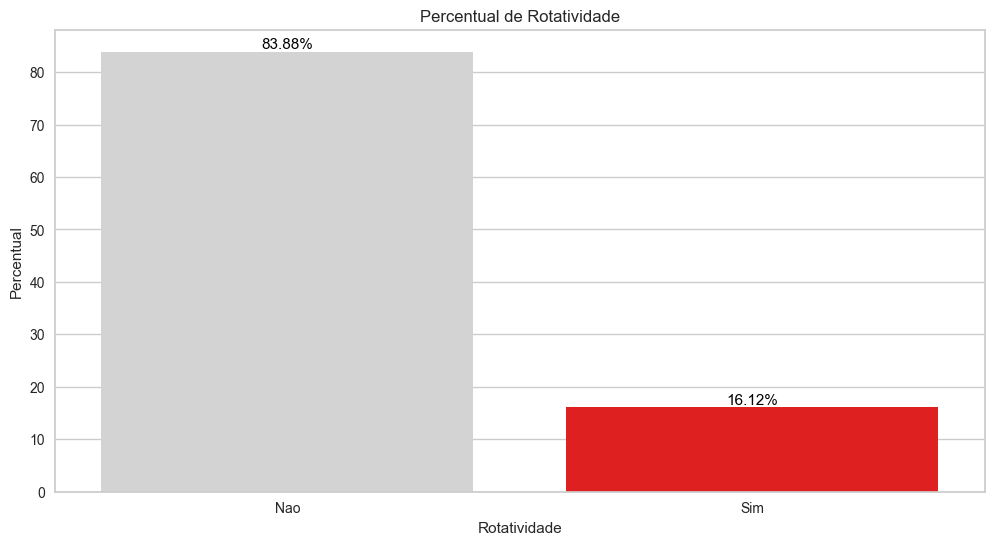

In [10]:
plt.figure(figsize=(12,6))

rotatividade_counts = df_publico['Rotatividade'].value_counts()

# Calculando os percentuais de rotatividade
percent_nao = (rotatividade_counts['Nao'] / len(df_publico)) * 100
percent_sim = (rotatividade_counts['Sim'] / len(df_publico)) * 100

# Criando o DataFrame total_by_rotatividade
total_by_rotatividade = pd.DataFrame({'Rotatividade': ['Nao', 'Sim'], 'Percent': [percent_nao, percent_sim]})

# Definindo as cores
cores = {'Nao': 'lightgrey', 'Sim': 'red'}

# Plotando o gráfico de barras com seaborn
ax = sns.barplot(x='Rotatividade', y='Percent', hue='Rotatividade', data=total_by_rotatividade, palette=cores, dodge=False)

# Adicionando os valores de cada barra com símbolo de porcentagem
for p in ax.patches:
    ax.annotate("{:.2f}%".format(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xlabel('Rotatividade')
plt.ylabel('Percentual')
plt.title('Percentual de Rotatividade')
plt.show()

Verifica-se que a taxa de rotatividade nesta base é 16,12%.

#### 2.5.4 Distribuição de Idade e Taxa de Rotatividade por Faixa de Idade

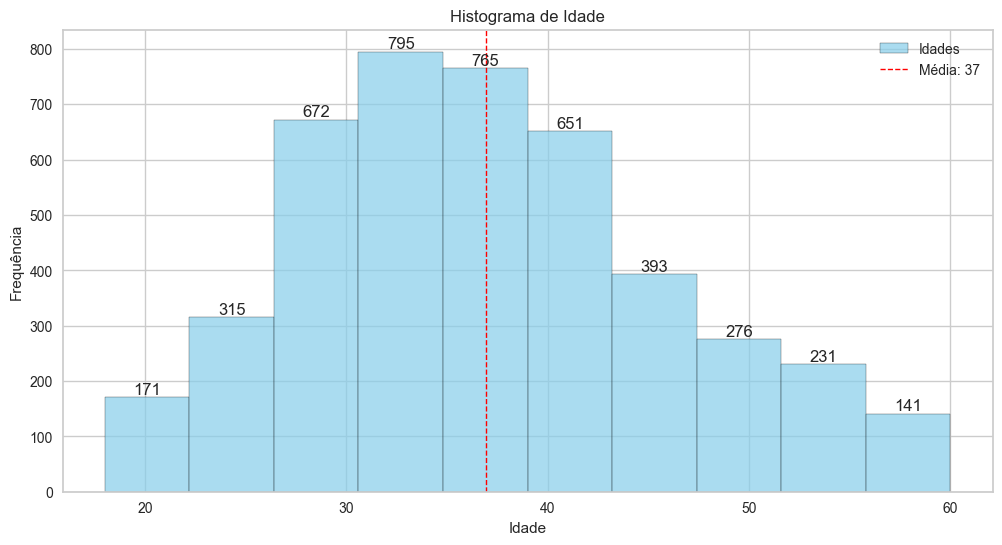

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plotando o histograma das idades
hist, bins, _ = plt.hist(df_publico['Idade'], bins=10, color='skyblue', edgecolor='black', alpha=0.7, label='Idades')

# Calculando a média das idades
media_idades = df_publico['Idade'].mean()

# Adicionando a linha vertical para a média
plt.axvline(media_idades, color='red', linestyle='dashed', linewidth=1)
plt.legend(['Idades', 'Média: {:.0f}'.format(media_idades)], loc='upper right')

# Adicionando os valores da frequência em cada barra
for i in range(len(hist)):
    plt.text(bins[i] + (bins[i+1] - bins[i]) / 2, hist[i], str(int(hist[i])), ha='center', va='bottom')

# Configurando os rótulos e título
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.title('Histograma de Idade')

# Mostrando o gráfico
plt.show()

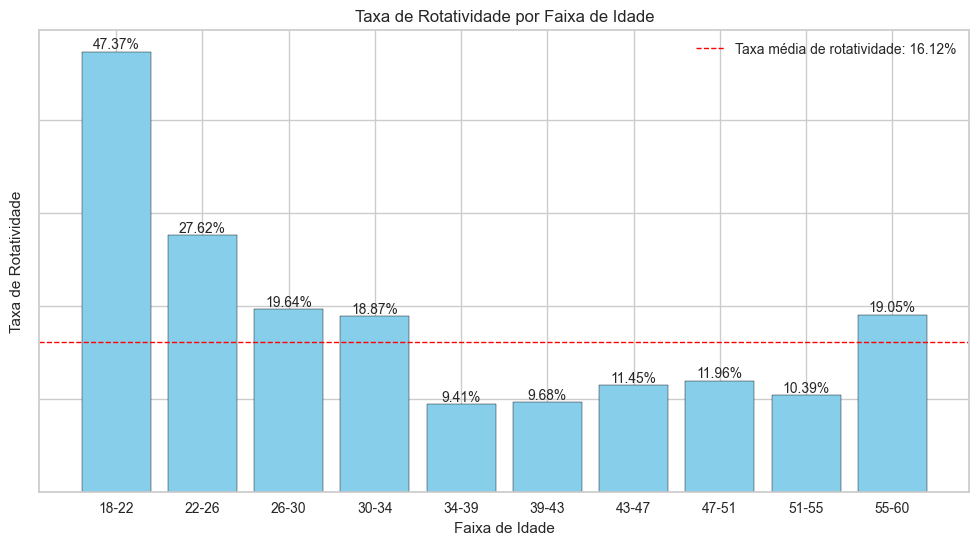

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Calculando o histograma das idades com os mesmos bins do histograma anterior
hist, bins = np.histogram(df_publico['Idade'], bins=10)

# Calculando a taxa de rotatividade para cada faixa de idade
taxa_rotatividade_por_faixa = []
for i in range(len(bins)-1):
    faixa_inferior = bins[i]
    faixa_superior = bins[i+1]
    taxa_rotatividade = df_publico[(df_publico['Idade'] >= faixa_inferior) & (df_publico['Idade'] < faixa_superior)]['Rotatividade'].value_counts(normalize=True).get('Sim', 0)
    taxa_rotatividade_por_faixa.append(taxa_rotatividade)

# Calculando a média da variável de rotatividade
taxa_media_rotatividade = df_publico['Rotatividade'].value_counts(normalize=True).get('Sim', 0)

# Plotando o gráfico de barras
plt.figure(figsize=(12,6))
plt.bar(range(len(bins)-1), taxa_rotatividade_por_faixa, color='skyblue', edgecolor='black')

# Adicionando os valores das taxas de rotatividade nas barras
for i, taxa in enumerate(taxa_rotatividade_por_faixa):
    plt.text(i, taxa, '{:.2f}%'.format(taxa * 100), ha='center', va='bottom', fontsize=10)

# Adicionando uma linha indicando a média da variável de rotatividade
plt.axhline(taxa_media_rotatividade, color='red', linestyle='dashed', linewidth=1, label='Taxa média de rotatividade: {:.2f}%'.format(taxa_media_rotatividade * 100))

# Adicionando as faixas de idade no eixo x
plt.xticks(range(len(bins)-1), ['{}-{}'.format(int(faixa_inf), int(faixa_sup)) for faixa_inf, faixa_sup in zip(bins[:-1], bins[1:])])

plt.gca().axes.yaxis.set_ticklabels([])

# Adicionando rótulos e título
plt.xlabel('Faixa de Idade')
plt.ylabel('Taxa de Rotatividade')
plt.title('Taxa de Rotatividade por Faixa de Idade')

# Adicionando a legenda
plt.legend()

# Mostrando o gráfico
plt.show()

Nota-se que:
* A idade mínima e máxima são respectivamente 18 e 60 anos;
* As duas faixas de idade com maior quantidade de funcionários são: 30-34 e 34-39 anos;
* Os funcionários da faixa de 18 a 22 anos são os que possuem maior taxa de rotatividade na empresa;
* As taxas de rotatividade são mais elevadas no público mais jovem, especificamente de 18 a 34 anos. Nas faixas de 34 a 55 anos apresenta uma redução significativa na taxa de rotatividade e volta a subir na última faixa de idade (55 a 60 anos).

Lembrar do critério de aposentadoria (2024):
* Tempo de Contribuição:
  *   Homens: 35 anos de contribuição;
  *   Mulheres: 30 anos de contribuição.
* Idade:
  *   Homens: 65 anos + 15 anos de contribuição;
  *   Mulheres: 62 anos + 15 anos de contribuição.



#### 2.5.5 Percentual de Funcionários por Gênero e Taxa de Rotatividade por Gênero

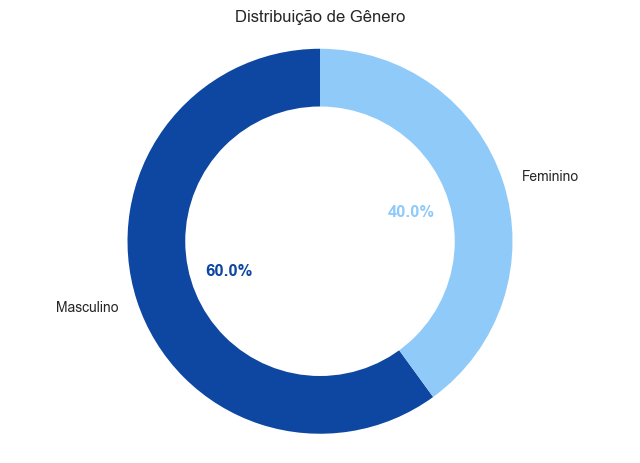

In [13]:
# Contando os valores únicos da variável 'Genero'
genero_counts = df_publico['Genero'].value_counts()

# Definindo os rótulos e os tamanhos das fatias
labels = genero_counts.index
sizes = genero_counts.values

# Cores das fatias
cores = ['#0D47A1', '#90CAF9']  # Defina as cores correspondentes a cada seção

# Criando o donut chart
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=cores, autopct='%1.1f%%', startangle=90,
                                  pctdistance=0.5)  # Define a distância dos valores percentuais do centro

# Adicionando um círculo no meio para transformar em donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Configurando o aspecto do gráfico
ax.axis('equal')

# Ajustando a posição e cor dos valores percentuais
for autotext, color in zip(autotexts, cores):
    autotext.set_color(color)  # Define a cor dos valores percentuais
    autotext.set_fontsize(12)  # Define o tamanho da fonte dos valores percentuais
    autotext.set_fontweight('bold')  # Define o peso da fonte dos valores percentuais

# Título
plt.title('Distribuição de Gênero')

# Mostrando o gráfico
plt.show()

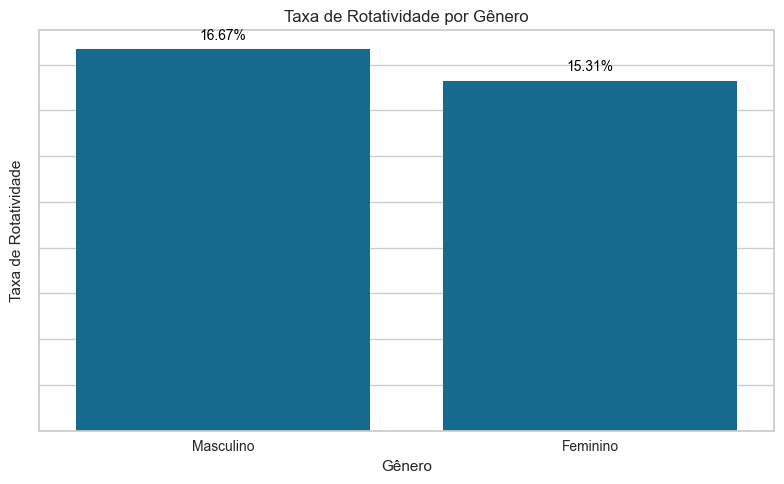

In [14]:
import matplotlib.pyplot as plt

# Calculando a taxa de rotatividade para cada gênero
taxa_rotatividade_por_genero = df_publico.groupby('Genero')['Rotatividade'].apply(lambda x: (x == 'Sim').mean())

# Ordenando os gêneros por taxa de rotatividade
generos_ordenados = taxa_rotatividade_por_genero.sort_values(ascending=False)

plt.figure(figsize=(8,5))

# Plotando o gráfico de barras com cor azul
ax = sns.barplot(x=generos_ordenados.index, y=generos_ordenados.values)

# Adicionando os valores de cada barra
for p in ax.patches:
    ax.annotate('{:.2f}%'.format(p.get_height() * 100), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.gca().axes.yaxis.set_ticklabels([])
plt.xlabel('Gênero')
plt.ylabel('Taxa de Rotatividade')
plt.title('Taxa de Rotatividade por Gênero')
plt.tight_layout()  # Ajusta o layout para evitar sobreposição de elementos
plt.show()

Verifica-se que:
* 60% dos funcionários são do gênero masculino enquanto 40% são do gênero feminino;
* Os funcionários do gênero masculino apresentam uma taxa de rotatividade um pouco mais elevada que as funcionárias do gênero feminino.

#### 2.5.6 Quantidade de Funcionários por Função e Taxa de Rotatividade por Função

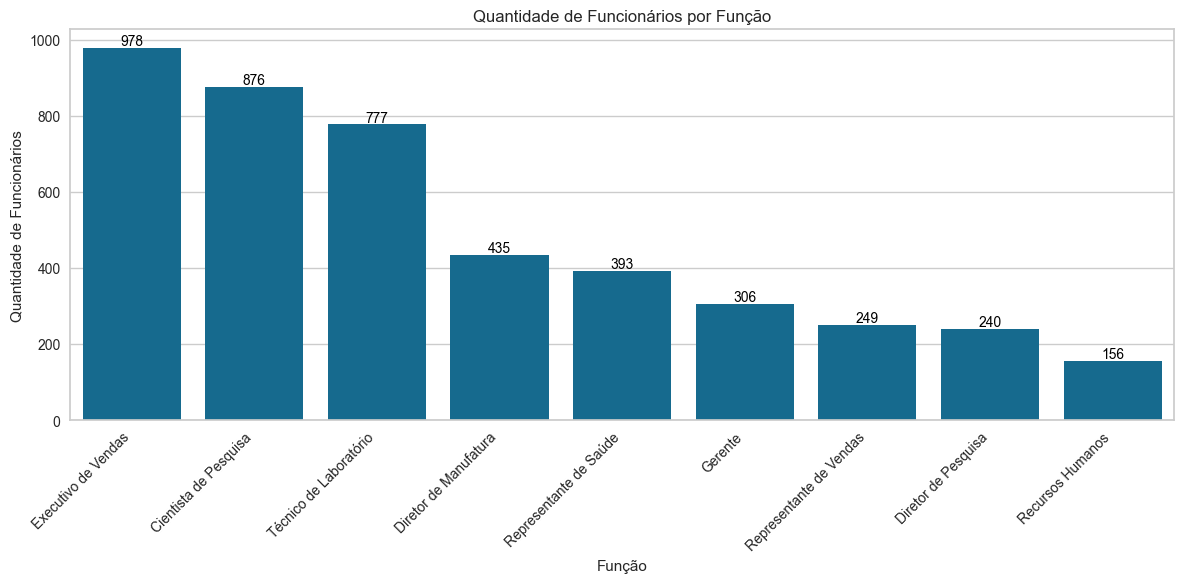

In [15]:
# Contando as ocorrências de cada categoria na variável 'Funcao' e ordenando em ordem decrescente
funcao_counts = df_publico['Funcao'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12,6))

# Plotando o gráfico de barras com seaborn e deixando o Seaborn gerenciar as cores
ax = sns.countplot(x='Funcao', data=df_publico, order=funcao_counts.index)

# Adicionando os valores de cada barra
for p in ax.patches:
    ax.annotate('{:.0f}'.format(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.xlabel('Função')
plt.ylabel('Quantidade de Funcionários')
plt.title('Quantidade de Funcionários por Função')
plt.xticks(rotation=45, ha='right')  # Rotaciona os rótulos do eixo x para melhor visualização
plt.tight_layout()  # Ajusta o layout para evitar sobreposição de elementos
plt.show()

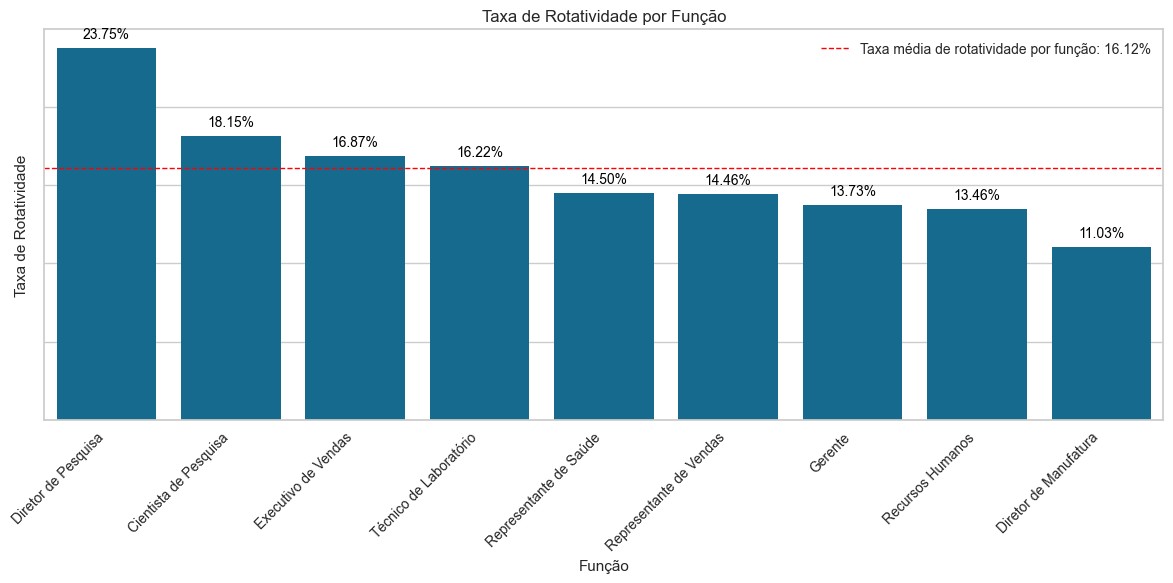

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a taxa de rotatividade para cada função
taxa_rotatividade_por_funcao = df_publico.groupby('Funcao')['Rotatividade'].apply(lambda x: (x == 'Sim').mean())

# Ordenando as funções por taxa de rotatividade
funcoes_ordenadas = taxa_rotatividade_por_funcao.sort_values(ascending=False)

plt.figure(figsize=(12,6))

# Plotando o gráfico de barras com cor azul
ax = sns.barplot(x=funcoes_ordenadas.index, y=funcoes_ordenadas.values)

# Adicionando os valores de cada barra
for p in ax.patches:
    ax.annotate('{:.2f}%'.format(p.get_height() * 100), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.gca().axes.yaxis.set_ticklabels([])

# Adicionando uma linha indicando a taxa média de rotatividade
taxa_media_rotatividade_funcao = df_publico['Rotatividade'].value_counts(normalize=True).get('Sim', 0)
plt.axhline(taxa_media_rotatividade_funcao, color='red', linestyle='dashed', linewidth=1, label='Taxa média de rotatividade por função: {:.2f}%'.format(taxa_media_rotatividade_funcao * 100))

plt.xlabel('Função')
plt.ylabel('Taxa de Rotatividade')
plt.title('Taxa de Rotatividade por Função')
plt.xticks(rotation=45, ha='right')  # Rotaciona os rótulos do eixo x para melhor visualização
plt.tight_layout()  # Ajusta o layout para evitar sobreposição de elementos

# Adicionando a legenda
plt.legend()

plt.show()

Observa-se que:
* As três funções que concentram quase 60% do total de funcionários são: Executivo de Vendas, Cientista de Pesquisa e Técnico de Laboratório;
* A função com maior taxa de rotatividade é Diretor de Pesquisa, apresentando taxa bem maior que a média na empresa;
* Diretor de Manufatura é a função com menor taxa de rotatividade na RetailX.

#### 2.5.7 Distribuição de Renda Mensal e Taxa de Rotatividade por Faixa de Renda Mensal

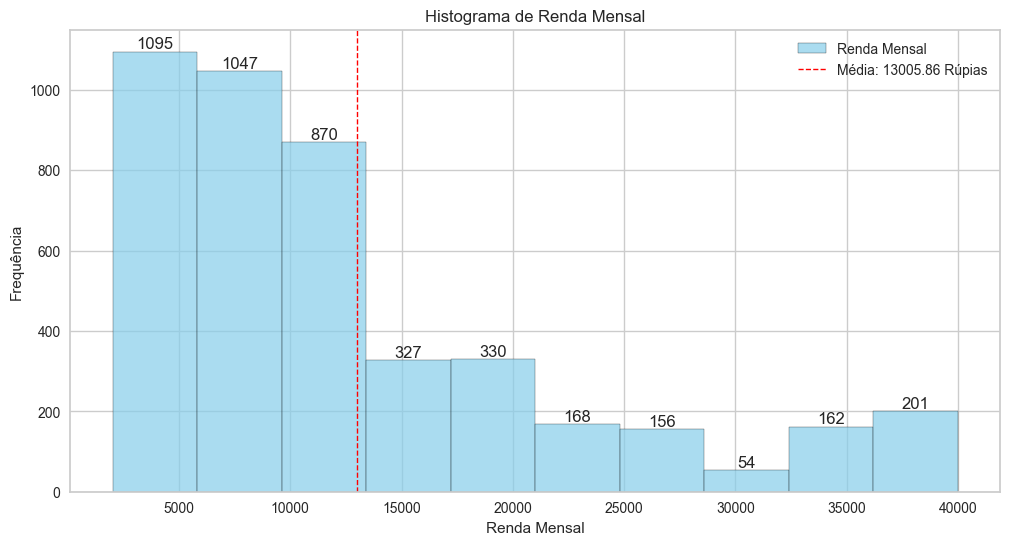

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plotando o histograma das rendas mensais
hist, bins, _ = plt.hist(df_publico['RendaMensal'], bins=10, color='skyblue', edgecolor='black', alpha=0.7, label='Renda Mensal')

# Calculando a média das rendas mensais
media_renda = df_publico['RendaMensal'].mean()

# Adicionando a linha vertical para a média
plt.axvline(media_renda, color='red', linestyle='dashed', linewidth=1)
plt.legend(['Renda Mensal', 'Média: {:.2f} Rúpias'.format(media_renda)], loc='upper right')

# Adicionando os valores da frequência em cada barra
for i in range(len(hist)):
    plt.text(bins[i] + (bins[i+1] - bins[i]) / 2, hist[i], str(int(hist[i])), ha='center', va='bottom')

# Configurando os rótulos e título
plt.xlabel('Renda Mensal')
plt.ylabel('Frequência')
plt.title('Histograma de Renda Mensal')

# Mostrando o gráfico
plt.show()

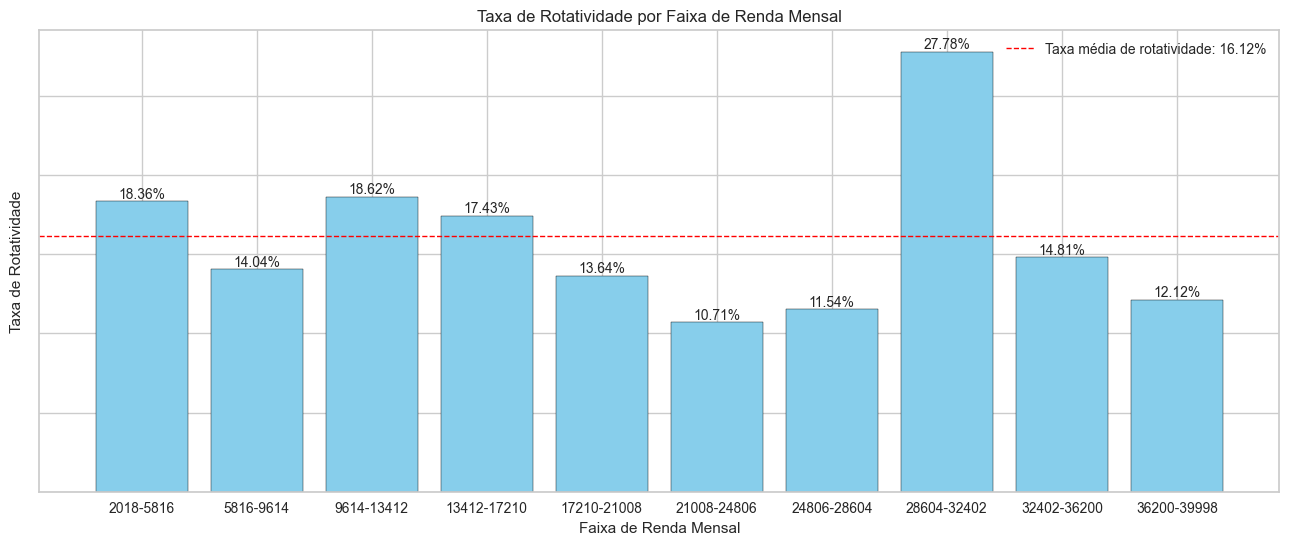

In [18]:
import matplotlib.pyplot as plt

# Calculando o histograma das rendas mensais com os mesmos bins do histograma anterior
hist, bins = np.histogram(df_publico['RendaMensal'], bins=10)

# Calculando a taxa de rotatividade para cada faixa de renda mensal
taxa_rotatividade_por_faixa = []
for i in range(len(bins)-1):
    faixa_inferior = bins[i]
    faixa_superior = bins[i+1]
    taxa_rotatividade = df_publico[(df_publico['RendaMensal'] >= faixa_inferior) & (df_publico['RendaMensal'] < faixa_superior)]['Rotatividade'].value_counts(normalize=True).get('Sim', 0)
    taxa_rotatividade_por_faixa.append(taxa_rotatividade)

# Calculando a média da variável de rotatividade
taxa_media_rotatividade = df_publico['Rotatividade'].value_counts(normalize=True).get('Sim', 0)

# Plotando o gráfico de barras
plt.figure(figsize=(16,6))
plt.bar(range(len(bins)-1), taxa_rotatividade_por_faixa, color='skyblue', edgecolor='black')

# Adicionando os valores das taxas de rotatividade nas barras
for i, taxa in enumerate(taxa_rotatividade_por_faixa):
    plt.text(i, taxa, '{:.2f}%'.format(taxa * 100), ha='center', va='bottom', fontsize=10)

# Adicionando uma linha indicando a média da variável de rotatividade
plt.axhline(taxa_media_rotatividade, color='red', linestyle='dashed', linewidth=1, label='Taxa média de rotatividade: {:.2f}%'.format(taxa_media_rotatividade * 100))

# Adicionando as faixas de renda mensal no eixo x
plt.xticks(range(len(bins)-1), ['{}-{}'.format(int(faixa_inf), int(faixa_sup)) for faixa_inf, faixa_sup in zip(bins[:-1], bins[1:])])

plt.gca().axes.yaxis.set_ticklabels([])

# Adicionando rótulos e título
plt.xlabel('Faixa de Renda Mensal')
plt.ylabel('Taxa de Rotatividade')
plt.title('Taxa de Rotatividade por Faixa de Renda Mensal')

# Adicionando a legenda
plt.legend()

# Mostrando o gráfico
plt.show()

Nota-se que:
* A maior parte dos funcionários (68%) tem uma renda mensal de até 13412 rúpias;
* Não há uma relação monotônica entre a faixa de renda e a taxa de rotatividade;
* A faixa de 28604 a 32402 rúpias, correspondente a 1,2% do público, apresenta uma taxa de rotatividade bem acima das demais faixas.

# 3. Preparação dos Dados

## 3.1 Encoding

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import pandas as pd

X = df_publico.drop(columns='IDDoEmpregado')

cat_attributes = X.select_dtypes(include='str')
num_attributes = X.select_dtypes(exclude='object')

# Define categorical pipeline
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

# Define numerical pipeline with RobustScaler
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Combine categorical and numerical pipelines
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_attributes.columns),
    ('num', num_pipe, num_attributes.columns)
])

pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

# Aplica o pipeline à base de dados
X_processed = pipeline.fit_transform(X)

# Obtém os nomes das colunas após o one-hot encoding
encoded_cat_columns = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']\
    .get_feature_names_out(input_features=cat_attributes.columns)

# Combina os nomes das colunas categóricas codificadas e as colunas numéricas
all_columns = list(encoded_cat_columns) + list(num_attributes.columns)

# Cria um DataFrame com as colunas pré-processadas e seus nomes
df_X_processed = pd.DataFrame(X_processed, columns=all_columns)

In [20]:
df_X_processed.head()

,Rotatividade_Sim,ViagensDeNegocio_Viagens_Frequentes,ViagensDeNegocio_Viagens_Raras,Departamento_Recursos_Humanos,Departamento_Vendas,CampoDeEducacao_Grau Técnico,CampoDeEducacao_Marketing,CampoDeEducacao_Médica,CampoDeEducacao_Outro,CampoDeEducacao_Recursos Humanos,...,TotalDeAnosTrabalhados,TreinamentosNoUltimoAno,AnosNaEmpresa,AnosDesdeUltimaPromocao,AnosComAtualGestor,SatisfacaoComAmbiente,SatisfacaoNoTrabalho,EquilibrioTrabalhoVida,EnvolvimentoNoTrabalho,AvaliacaoDeDesempenho
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-1.000000,3.0,-0.666667,-0.333333,-0.6,0.0,0.5,-1.0,0.0,0.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.444444,0.0,0.000000,0.000000,0.2,0.0,-0.5,1.0,-1.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,-0.555556,-1.0,0.000000,-0.333333,0.0,-0.5,-0.5,-2.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.333333,2.0,0.500000,2.000000,0.4,0.5,0.5,0.0,-1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.111111,-1.0,0.166667,-0.333333,0.2,0.5,-1.0,0.0,0.0,0.0


## 3.2 Redução de Dimensionalidade

In [21]:
df_X_processed.shape

(4410, 41)

In [22]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 0.80)
pca.fit(df_X_processed)
df_reduced = pca.transform(df_X_processed)
df_reduced.shape

(4410, 16)

# 4. Modelagem

## 4.1 Clusterização

### 4.1.1.1 Método da Silhueta para escolha do número de Clusters

Iteração número: 0 - Coeficiente de Silhueta: 0.18811589213606353 - Tempo gasto na iteração: 5.552870988845825 segundos
Iteração número: 1 - Coeficiente de Silhueta: 0.1082108524884413 - Tempo gasto na iteração: 0.5952668190002441 segundos
Iteração número: 2 - Coeficiente de Silhueta: 0.10549308976914555 - Tempo gasto na iteração: 0.5036985874176025 segundos
Iteração número: 3 - Coeficiente de Silhueta: 0.07217472173626038 - Tempo gasto na iteração: 0.4749140739440918 segundos
Iteração número: 4 - Coeficiente de Silhueta: 0.10025854069836518 - Tempo gasto na iteração: 0.4652740955352783 segundos
Iteração número: 5 - Coeficiente de Silhueta: 0.10037993317707782 - Tempo gasto na iteração: 0.5186805725097656 segundos
Iteração número: 6 - Coeficiente de Silhueta: 0.08002151619477489 - Tempo gasto na iteração: 0.508563756942749 segundos
Iteração número: 7 - Coeficiente de Silhueta: 0.08172380307549597 - Tempo gasto na iteração: 0.41486358642578125 segundos


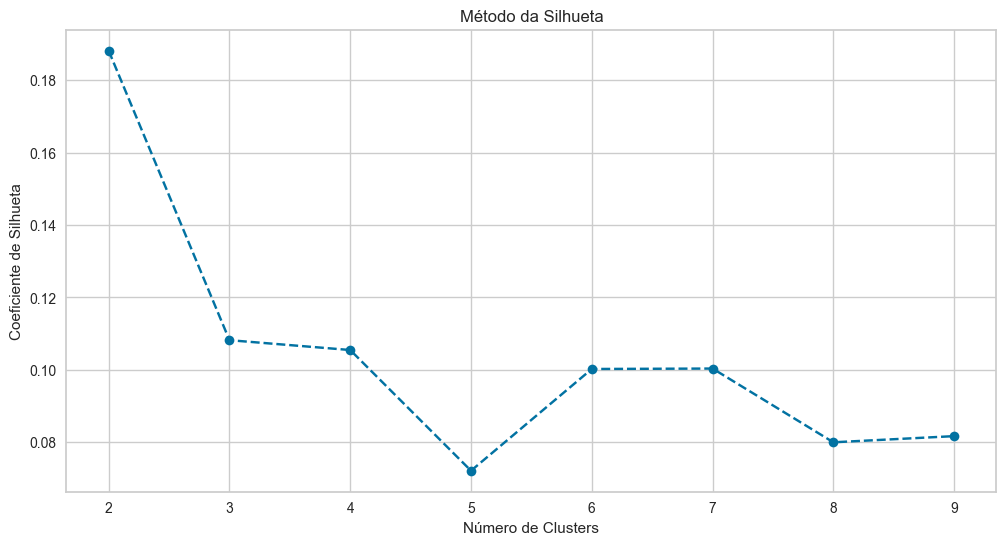

In [23]:
# Calcular a pontuação da silhueta para diferentes números de clusters
silhouette_scores = []
i = 0
k_min = 2
k_max = 10

for n_clusters in range(k_min, k_max):
    start_time = time.time()
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto')
    cluster_labels = kmeans.fit_predict(df_reduced)
    # gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=0)
    # gmm.fit(df_reduced)
    # cluster_labels = gmm.predict(df_reduced)

    # spectral_clustering = SpectralClustering(n_clusters=n_clusters, affinity='rbf', gamma=15, random_state=42)
    # cluster_labels = spectral_clustering.fit_predict(df_reduced)
    silhouette_avg = silhouette_score(df_reduced, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    end_time = time.time()
    elapsed_time = end_time - start_time

    print(f'Iteração número: {i} - Coeficiente de Silhueta: {silhouette_avg} - Tempo gasto na iteração: {elapsed_time} segundos')
    i += 1

# Plotar o gráfico do método da silhueta
plt.figure(figsize=(12, 6))
plt.plot(range(k_min, k_max), silhouette_scores, marker='o', linestyle='--', color='b')
plt.xlabel('Número de Clusters')
plt.ylabel('Coeficiente de Silhueta')
plt.title('Método da Silhueta')
plt.xticks(range(k_min, k_max))
plt.grid(True)
plt.show()

In [24]:
# Silhouette Score for K means
# Import ElbowVisualizer
from yellowbrick.cluster import KElbowVisualizer

plt.figure(figsize=(12, 6))
model = KMeans(random_state=0, n_init='auto')
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=True)
visualizer.fit(df_reduced)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

YellowbrickTypeError: The supplied model is not a clustering estimator; try a classifier or regression score visualizer instead!

<Figure size 1200x600 with 0 Axes>

### 4.1.1.2 Método do Cotovelo para escolha do número de Clusters

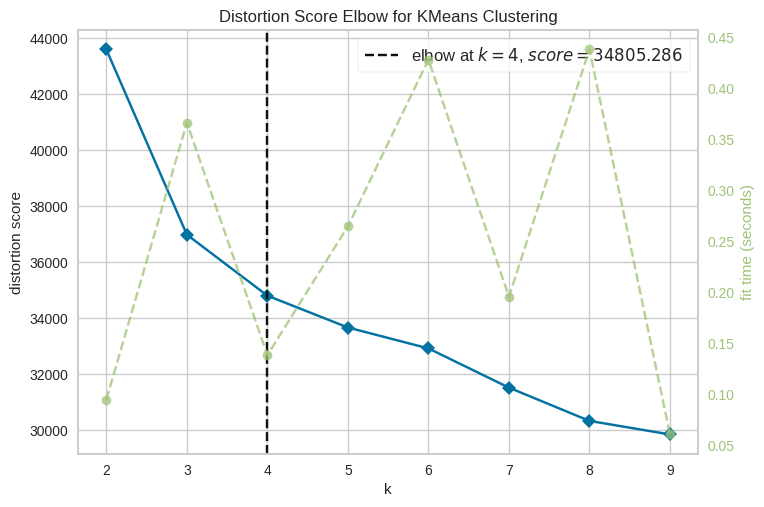

In [24]:
# Elbow Method for K means
# Import ElbowVisualizer
from yellowbrick.cluster import KElbowVisualizer
model = KMeans(random_state=0, n_init='auto')
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(2,10), timings= True);
visualizer.fit(df_reduced)        # Fit data to visualizer
visualizer.show();        # Finalize and render figure

### 4.1.2 Treinar modelo de Clusterização

#### 4.1.2.1 K-Means

In [48]:
# Treinar o algoritmo K-means com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(df_reduced)

# Obter os centróides dos clusters
centroids = kmeans.cluster_centers_
labels = kmeans.labels_

df_publico['Cluster'] = labels

np.unique(labels)

array([0, 1, 2], dtype=int32)

#### 4.1.2.2 Modelo de Mistura Gaussiana

##### 4.1.2.2.1 Seleção da quantidade de componentes

In [43]:
from sklearn.mixture import GaussianMixture

n_components = range(1, 10)
covariance_type = ['spherical', 'tied', 'diag', 'full']
best_bic = float('inf')  # Inicialize com um valor infinito
best_config = None
bic_scores = []

for cov in covariance_type:
    for n_comp in n_components:
        gmm = GaussianMixture(n_components=n_comp, covariance_type=cov, random_state=0)
        gmm.fit(df_reduced)
        bic_score = gmm.bic(df_reduced)
        bic_scores.append((cov, n_comp, bic_score))

        if bic_score < best_bic:
            best_bic = bic_score
            best_config = (cov, n_comp)

print("Melhor configuração:", best_config)
print("Menor BIC:", best_bic)

Melhor configuração: ('full', 7)
Menor BIC: 146702.32916079328


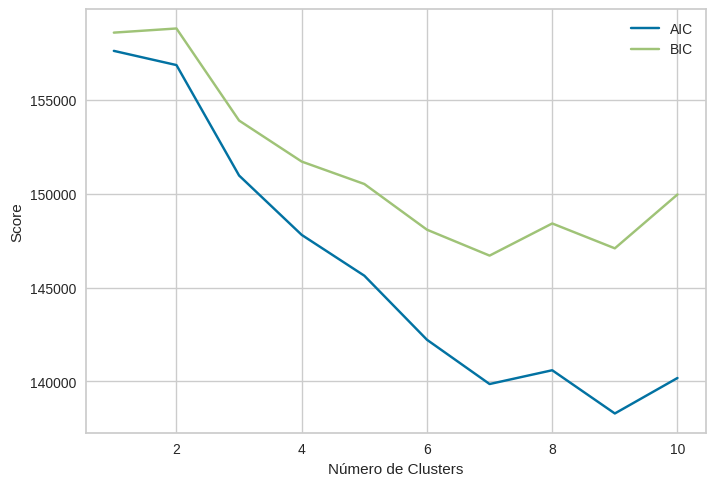

In [27]:
from sklearn.mixture import GaussianMixture
import numpy as np

# Lista para armazenar valores de AIC e BIC
aic_scores = []
bic_scores = []

# Testar diferentes números de clusters
for n_clusters in range(1, 11):
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=0)
    gmm.fit(df_reduced)
    aic_scores.append(gmm.aic(df_reduced))
    bic_scores.append(gmm.bic(df_reduced))

# Plotar AIC e BIC em função do número de clusters
import matplotlib.pyplot as plt

plt.plot(range(1, 11), aic_scores, label='AIC')
plt.plot(range(1, 11), bic_scores, label='BIC')
plt.xlabel('Número de Clusters')
plt.ylabel('Score')
plt.legend()
plt.show()

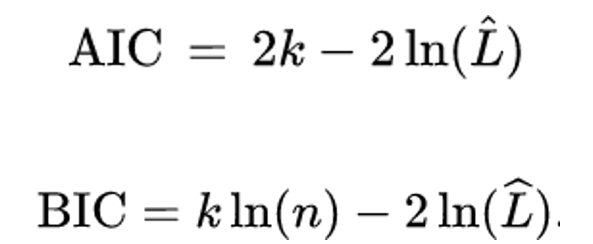

##### 4.1.2.2.2 Treino do Modelo

In [51]:
from sklearn.mixture import GaussianMixture
# Inicializar o modelo de Mistura Gaussiana
gmm = GaussianMixture(n_components=7, covariance_type='full', random_state=0)

# Ajustar o modelo aos dados com parâmetros de inicialização específicos
gmm.fit(df_reduced)

# Prever os rótulos dos clusters
labels = gmm.predict(df_reduced)

df_publico['Cluster'] = labels

np.unique(labels)

array([0, 1, 2, 3, 4, 5, 6])

### 4.1.3 Análise dos Clusters Gerados

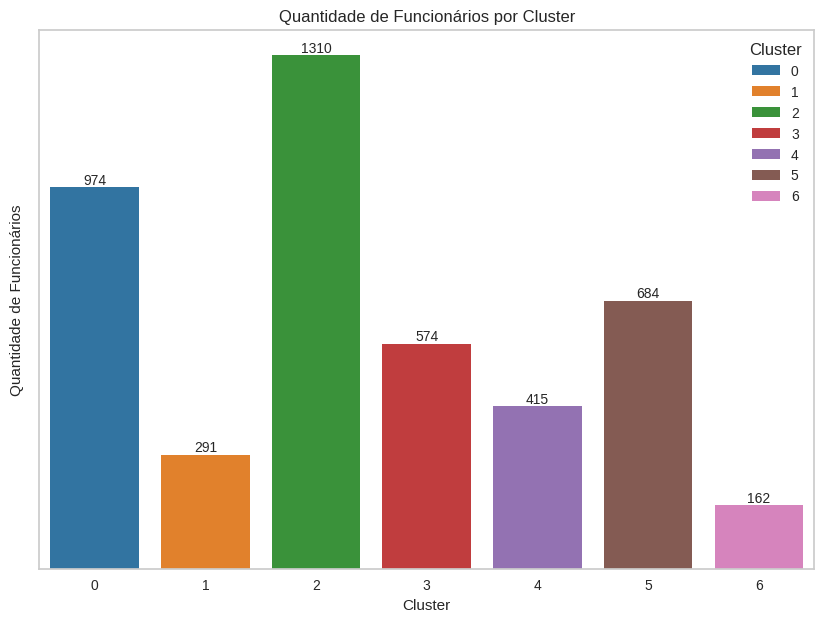

In [52]:
pal = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
pal = pal[:len(np.unique(labels))]

plt.figure(figsize=(10,7))
pl = sns.countplot(data=df_publico, x="Cluster",hue="Cluster",palette=pal)

for i in range(len(pl.containers)):
  pl.bar_label(pl.containers[i], fontsize=10)
pl.set_title("Quantidade de Funcionários por Cluster")
plt.gca().axes.yaxis.set_ticklabels([])
plt.ylabel('Quantidade de Funcionários')
plt.grid(False)
plt.show()

Nota-se que:
  * Praticamente 1/3 dos funcionários estão concentrados no cluster 2;
  * O segundo cluster com maior participação é o 0 representando 22% do total;
  * O cluster 6 teve a menor participação correspondendo a aproximadamente 3,7% do total.

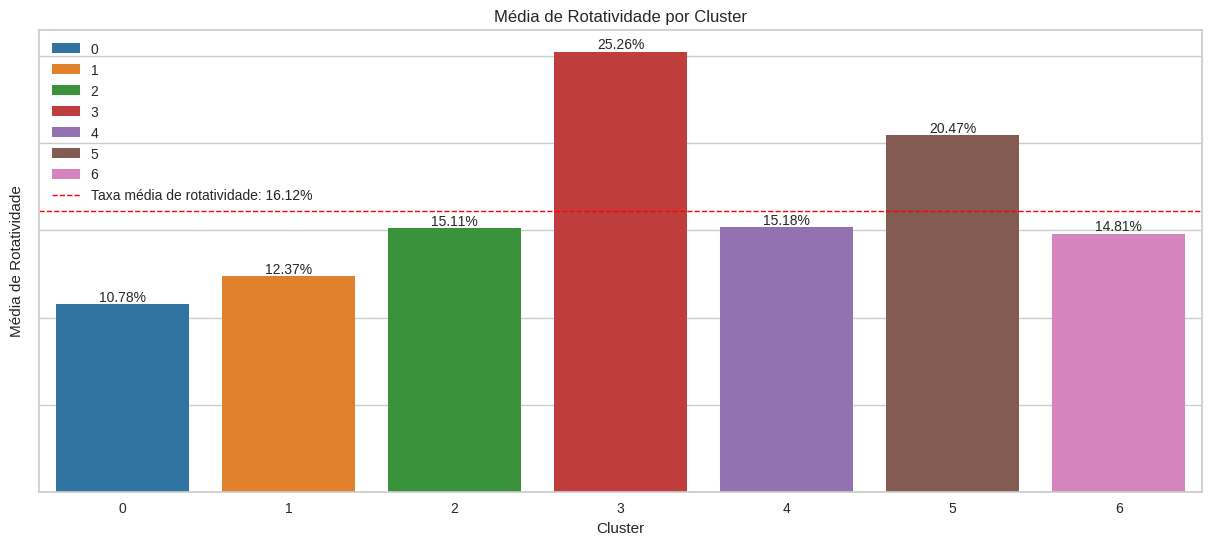

In [53]:
df_publico['TARGET'] = (df_publico['Rotatividade'] == 'Sim').astype(int)

# Calcular a média da variável "Rotatividade" para cada cluster
mean_rotatividade_by_cluster = df_publico.groupby("Cluster")["TARGET"].mean().reset_index()

# Plotar o gráfico de barras
plt.figure(figsize=(15, 6))
sns.barplot(x="Cluster", y="TARGET", data=mean_rotatividade_by_cluster, palette=pal, hue="Cluster")
plt.axhline(taxa_media_rotatividade, color='red', linestyle='dashed', linewidth=1, label='Taxa média de rotatividade: {:.2f}%'.format(taxa_media_rotatividade * 100))

plt.title("Média de Rotatividade por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Média de Rotatividade")



# Adicionando os valores das taxas de rotatividade nas barras
for i, taxa in enumerate(mean_rotatividade_by_cluster.TARGET.values):
    plt.text(i, taxa, '{:.2f}%'.format(taxa * 100), ha='center', va='bottom', fontsize=10)

plt.gca().axes.yaxis.set_ticklabels([])
plt.legend()
plt.show()

Verifica-se que:
 * Os clusters 3 e 5 são os que apresentam maior taxa de rotatividade com 25,3% e 20,5% respectivamente;
 * Todos os demais clusters apresentam menor rotatividade em percentual do que a média da empresa;
 * O Cluster 0 possui o menor percentual de rotatividade dentre todos os demais clusters.

In [1]:
# Variáveis a serem analisadas:
vars1 = list(cat_attributes.columns).copy()
vars1.remove('MaiorDe18')
vars1.remove('Rotatividade')

vars2 = ['SatisfacaoComAmbiente','SatisfacaoNoTrabalho','EquilibrioTrabalhoVida','EnvolvimentoNoTrabalho','AvaliacaoDeDesempenho','Educacao']

vars_categoricas = vars1 + vars2

for var in vars_categoricas:
  percentuais_por_cluster = df_publico.groupby('Cluster')[var].value_counts(normalize=True).mul(100).unstack().reset_index().values

  # Extrair os clusters e os percentuais de satisfação
  clusters = percentuais_por_cluster[:, 0]
  percentuais = percentuais_por_cluster[:, 1:]

  # Largura da barra
  bar_width = 0.1

  # Coordenadas das barras
  x = np.arange(len(clusters))

  # Plotar o gráfico de barras
  plt.figure(figsize=(10, 6))

  unicos = sorted(df_publico[var].unique())
  for i in range(len(percentuais[0])):
      j = unicos[i]
      plt.bar(x + i * bar_width, percentuais[:, i], bar_width, label=f'{j}')
      for j, val in enumerate(percentuais[:, i]):
          plt.text(x[j] + i * bar_width, val, '{:.1f}%'.format(val), ha='center', va='bottom', fontsize=9)

  # Adicionar rótulos e título
  plt.xlabel('Clusters')
  plt.ylabel('Percentual')
  plt.title(f'Percentual de {var} por Cluster')
  plt.xticks(x + bar_width * len(percentuais[0]) / 2, [f'Cluster {int(cluster)}' for cluster in clusters])
  plt.legend(loc='best')

  # Mostrar o gráfico
  plt.show()

NameError: name 'cat_attributes' is not defined

Insights gerados:
* Viagens de Negócio:
  * Os funcionários pertencentes aos clusters 0 e 2 raramente viajam à negócio;
  * 53% dos colaboradores incluindos no cluster 3 viajam com frequência;
  * 82,9% dos funcionários contidos no cluster 5 viajam (com frequência + raramente) a trabalho.
* Departamento:
  * Não houve diferença significativa entre a distribuição de departamento entre os clusters.
* Campo de Educação:
  * No cluster 6 não há funcionários do nível de Recursos Humanos;
  * Todos os clusters apresentam os Ciência da Vida e Médica como os mais representativos.
* Gênero:
  * O cluster com maior taxa de rotatividade (Cluster 3) apresenta a maior discrepância na distribuição em relação ao percentual de gênero tendo 69,2% do genêro masculino e 30,8% feminino;
  * O cluster 5, o segundo maior em taxa de rotatividade, apresenta 62,4% do gênero masculino e 37,6% feminino;
  * Em todos os clusters houve maior percentual de funcionários do gênero masculino do que feminino.
* Função:
  * Todas as funções estão contidas em todos os clusters;
  * O cluster 0 é o único em que a função de Técnico de Laboratório apresenta o maior percentual;
  * Os clusters 3 e 5 apresentam um padrão similar ao visto em outros clusters em que as 3 funções principais são: Executivo de vendas, Cientista de Pesquisa e Técnico de Laboratório.
* Estado Civil:
  * O cluster 0 apresenta o maior percentual de funcionários que são casados e menor percentual de divórciados;
  * O estado civil casado é o dominante em todos os clusters;
  * O cluster 5 possui o maior percentual de funcionários solteiros dentre os demais clusters;
  * O cluster 6 apresenta o maior percentual de divorciados.
* Satisfação com o Ambiente:
  * O cluster 3 apresenta percentualmente a maior concentração de funcionários com nível de satisfação com o ambiente igual 1;
  * O cluster 5 apresenta percentualmente a maior concentração de funcionários com nível de satisfação com o ambiente igual 2;
  * Os clusters 3 e 5 apresentam o menor percentual de nível satisfação com o ambiente igual a 4 dentre os demais clusters;
  * No cluster 0 64,4% dos funcionários apresentam nível de satisfação com o ambiente igual a 3 ou superior enquanto nos clusters 3 e 5 este valor corresponde a 50,4% e 63,1% respectivamente.
* Satisfação com o Trabalho:
  * Os clusters 3 apresenta o maior percentual de nível satisfação com o trabalho igual a 3 dentre os demais clusters;
  * No cluster 0 63,4% dos funcionários apresentam nível de satisfação com o ambiente igual a 3 ou superior enquanto nos clusters 3 e 5 este valor corresponde a 63,7% e 62,4% respectivamente.
* Equilíbrio Trabalho x Vida:
  * O nível de equilíbrio predominante em todos os clusters é 3 tendo o maior e menor percentual respectivamente nos clusters 4 e 6;
  * Em todos os clusters há predominância dos níveis 3 e 2.
* Envolvimento no Trabalho:
  * Em todos os clusters o nível de envolvimento no trabalho predominante foi 3;
  * No cluster 3, 67,4% dos funcionários tiveram nível de envolvimento no trabalho maior ou igual a 3. Enquanto no cluster 5, este valor foi de 67,9%. No cluster 0, por sua vez, foi de 72,3%.
* Avaliação de Desempenho:
  * Todos os funcionários da empresa obtiveram nível 3 ou 4;
  * O cluster 4 se destacou por apresentar o maior percentual de funcionários com nível 3;
  * O cluster 5 se destacou por obter maior percentual de colaboradores com nível 4.
* Educação:
  * O cluster 6 apresenta maior concentração percentual de bacharéis e menor concentração de doutores;
  * Em todos os clusters com exceção do cluster 1 o nível de bacharéu (nível 3) é o mais frequente. No cluster 1, há mais mestres (nível 4) que bacharéis;
  *  O cluster 3 apresenta a maior concentração percentual de funcionários com nível abaixo do superior (nível 1);
  * No cluster 3, 5 e 0 o valor percentual de funcionários que tem nível abaixo do superior ou no máximo ensino superior incompleto representa 33,5%; 32,1% e 28,6% respectivamente.

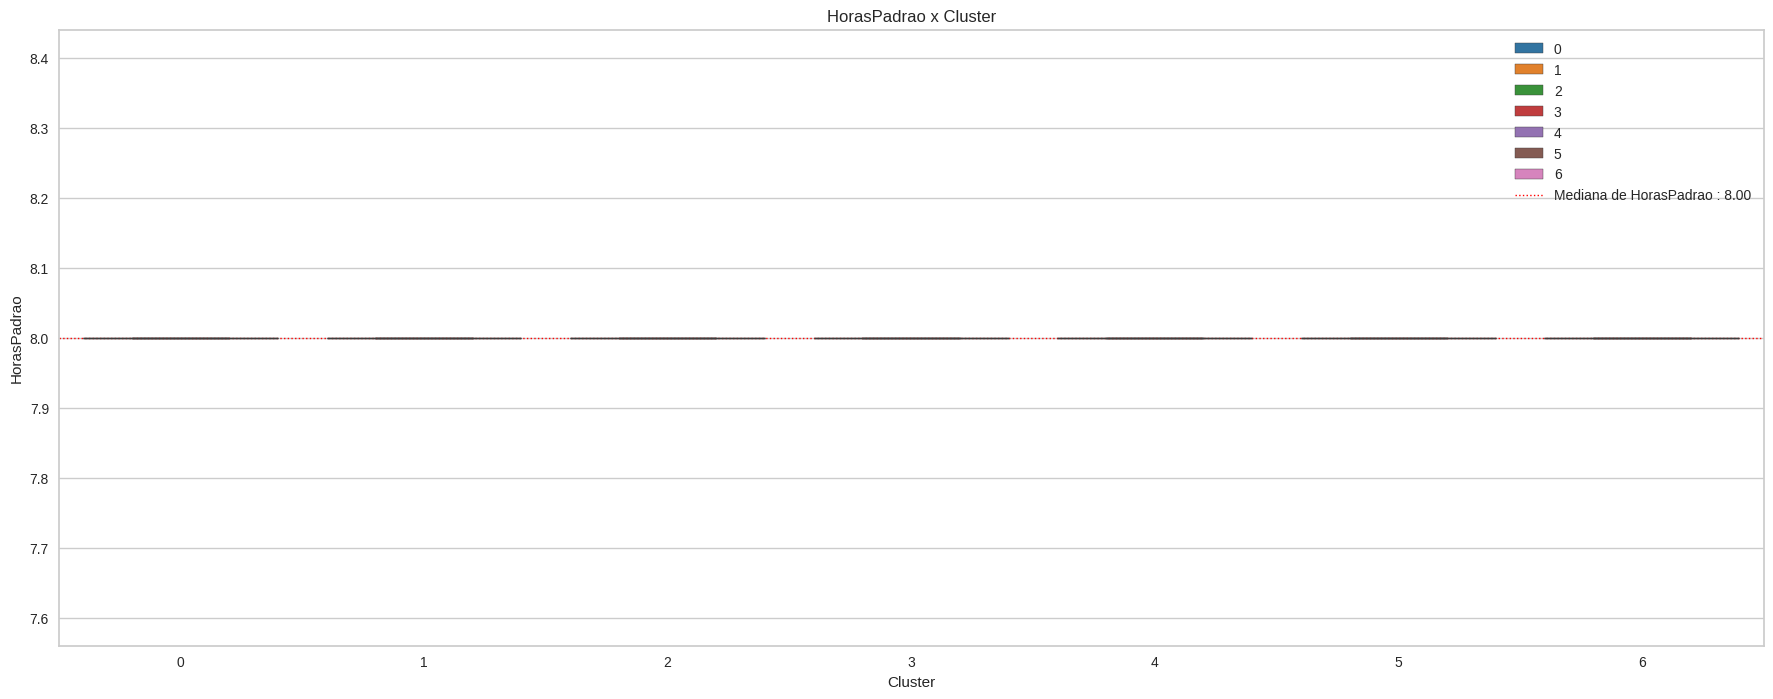

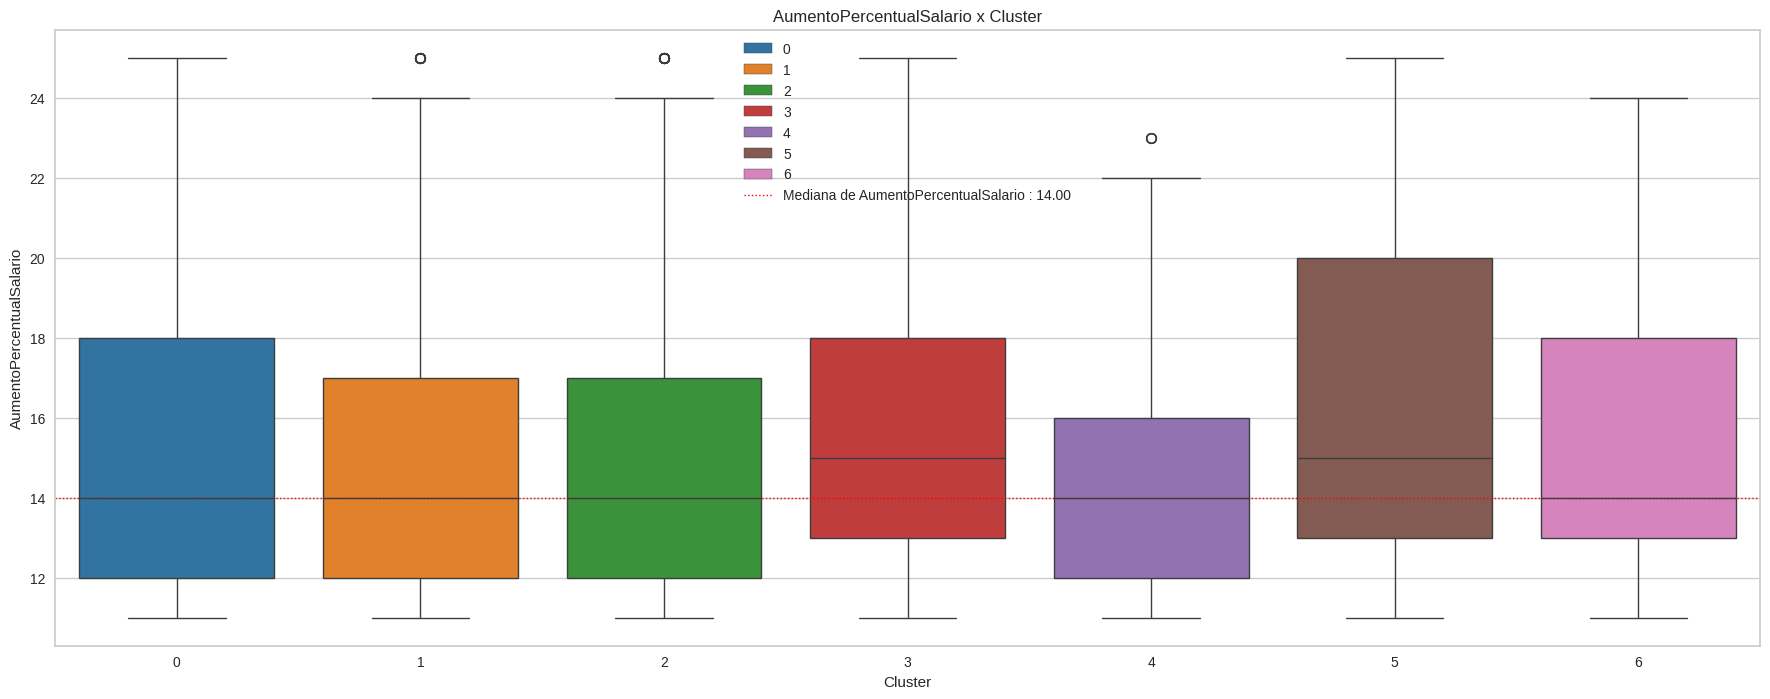

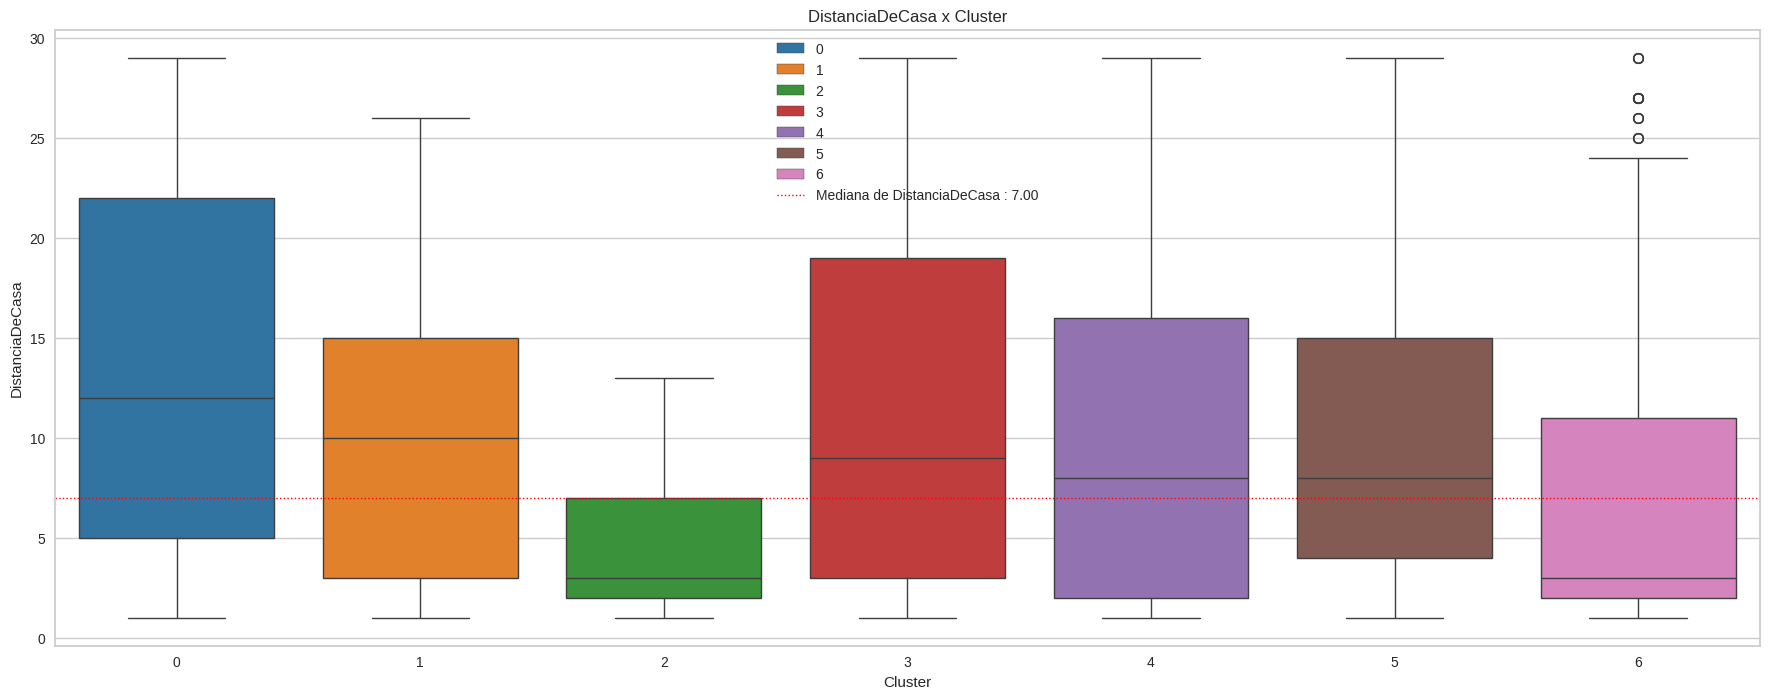

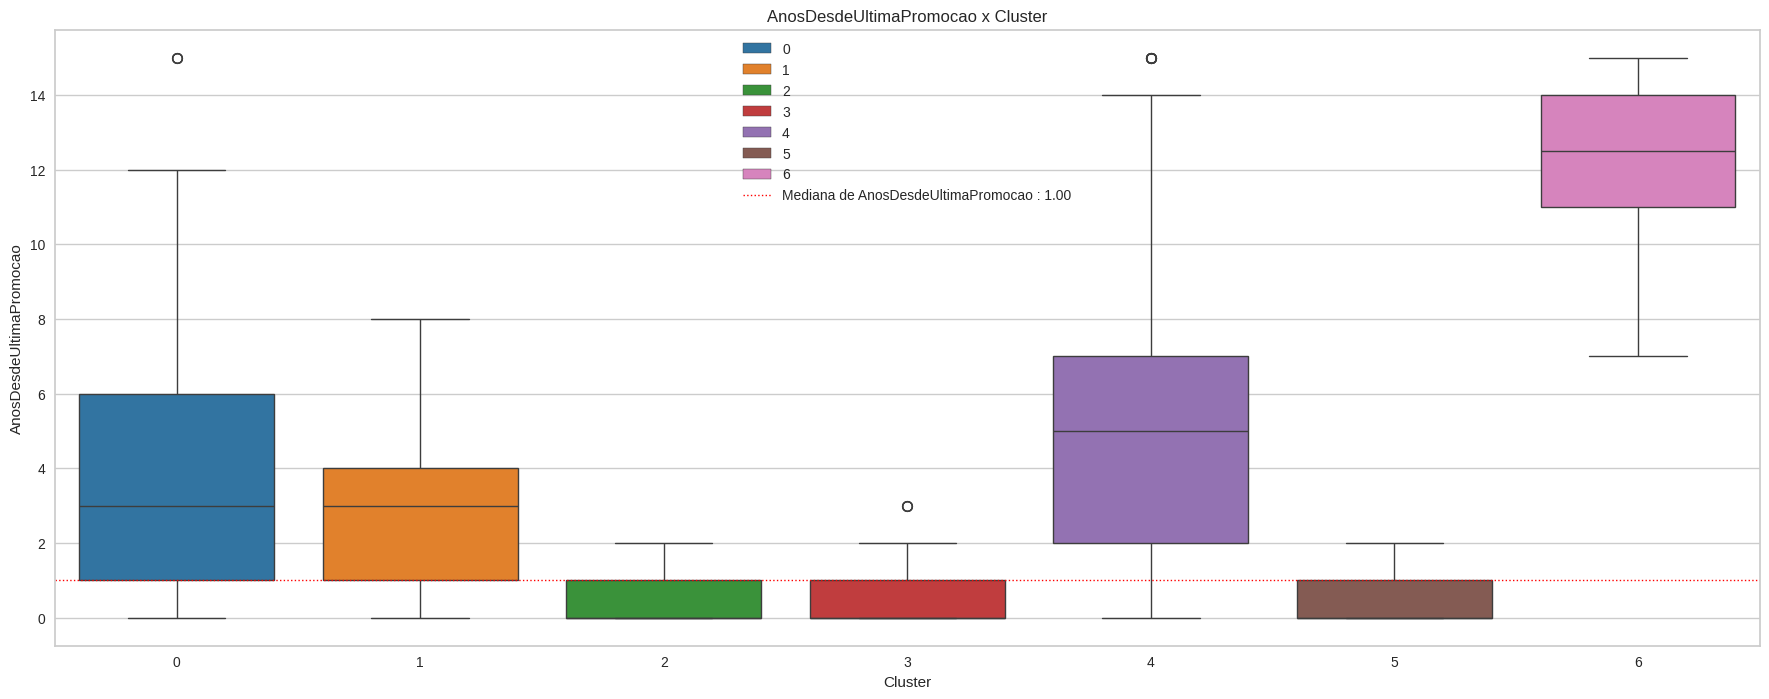

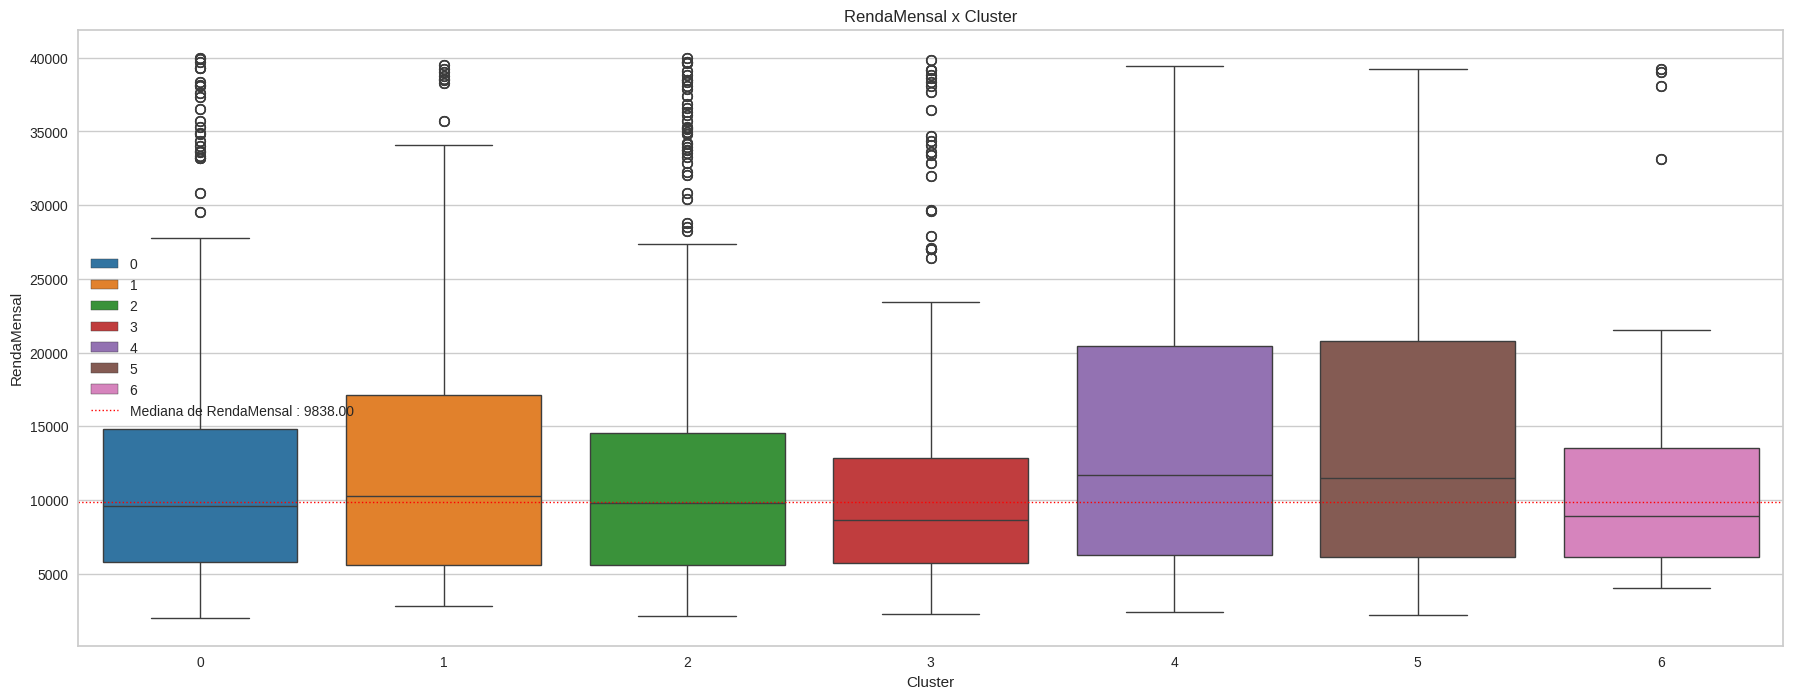

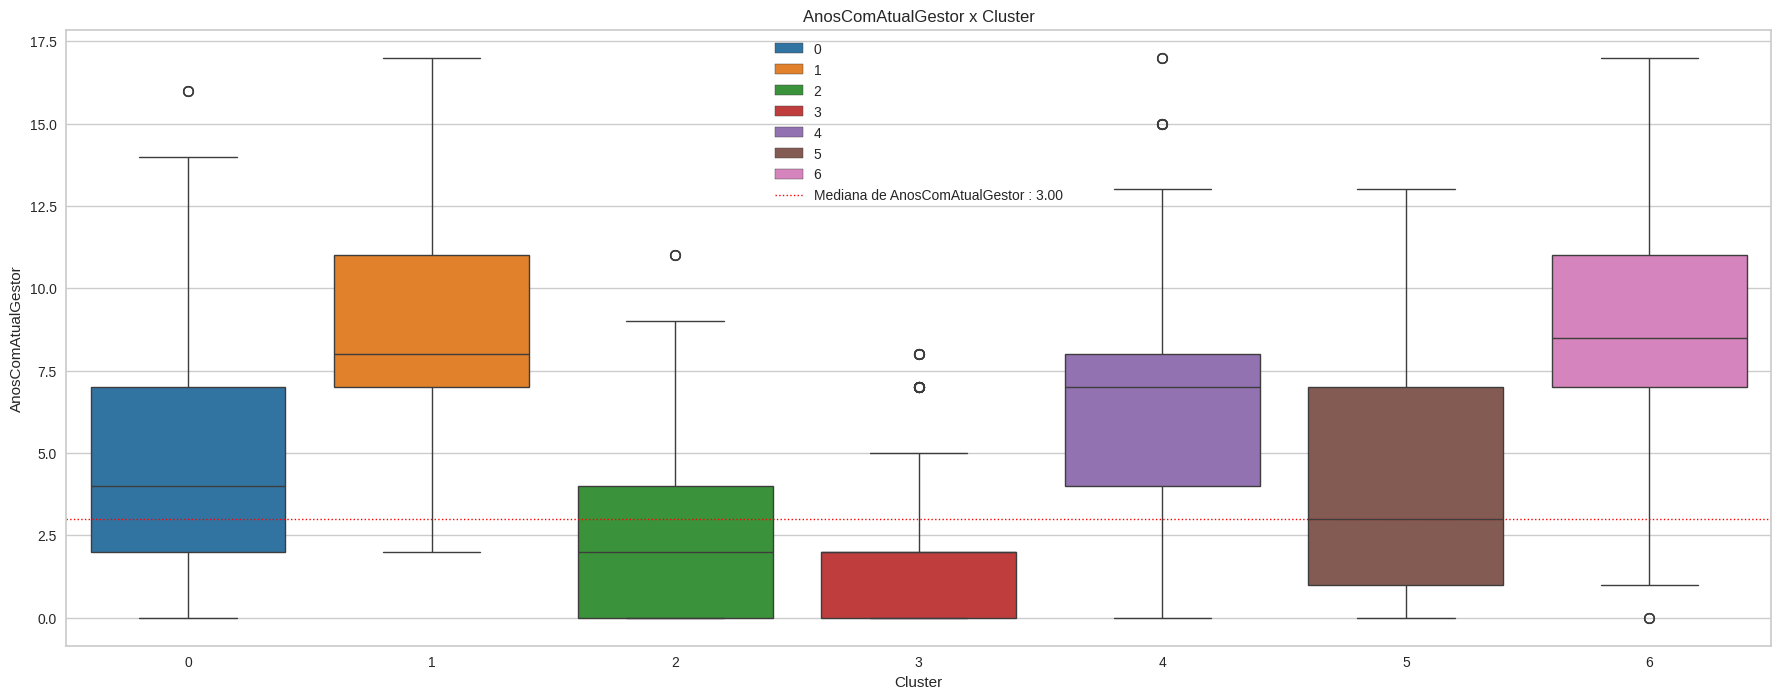

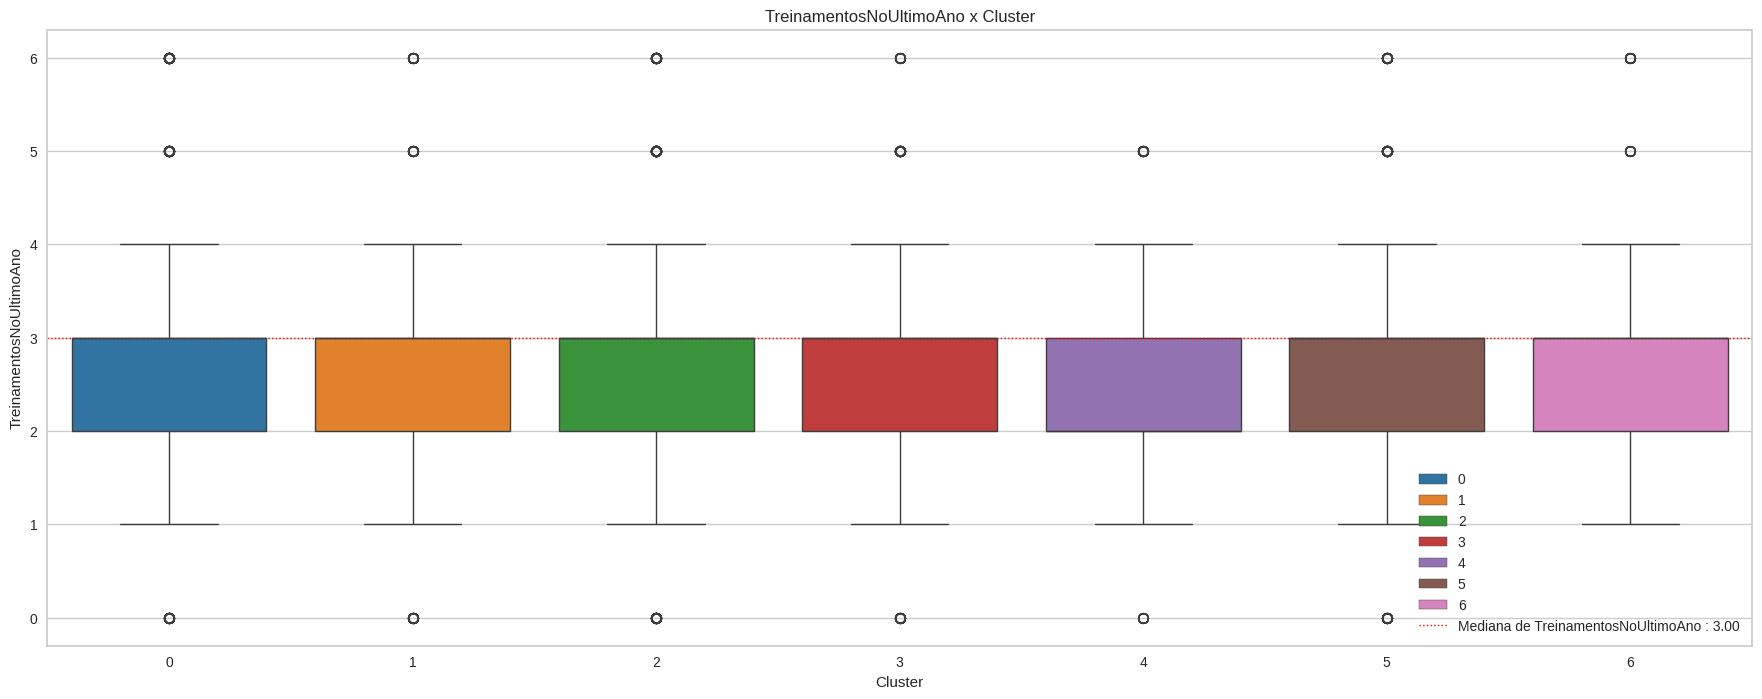

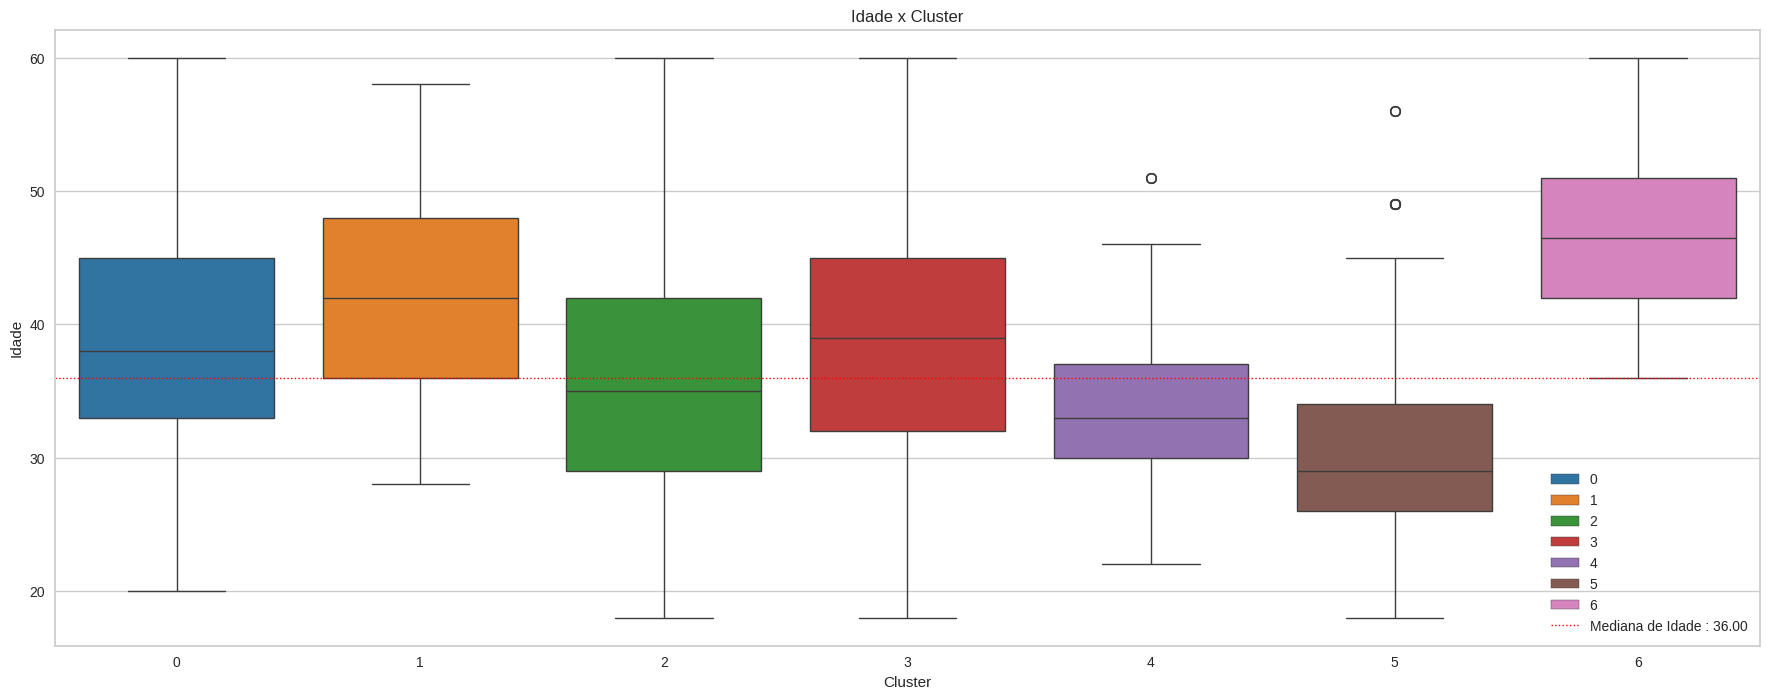

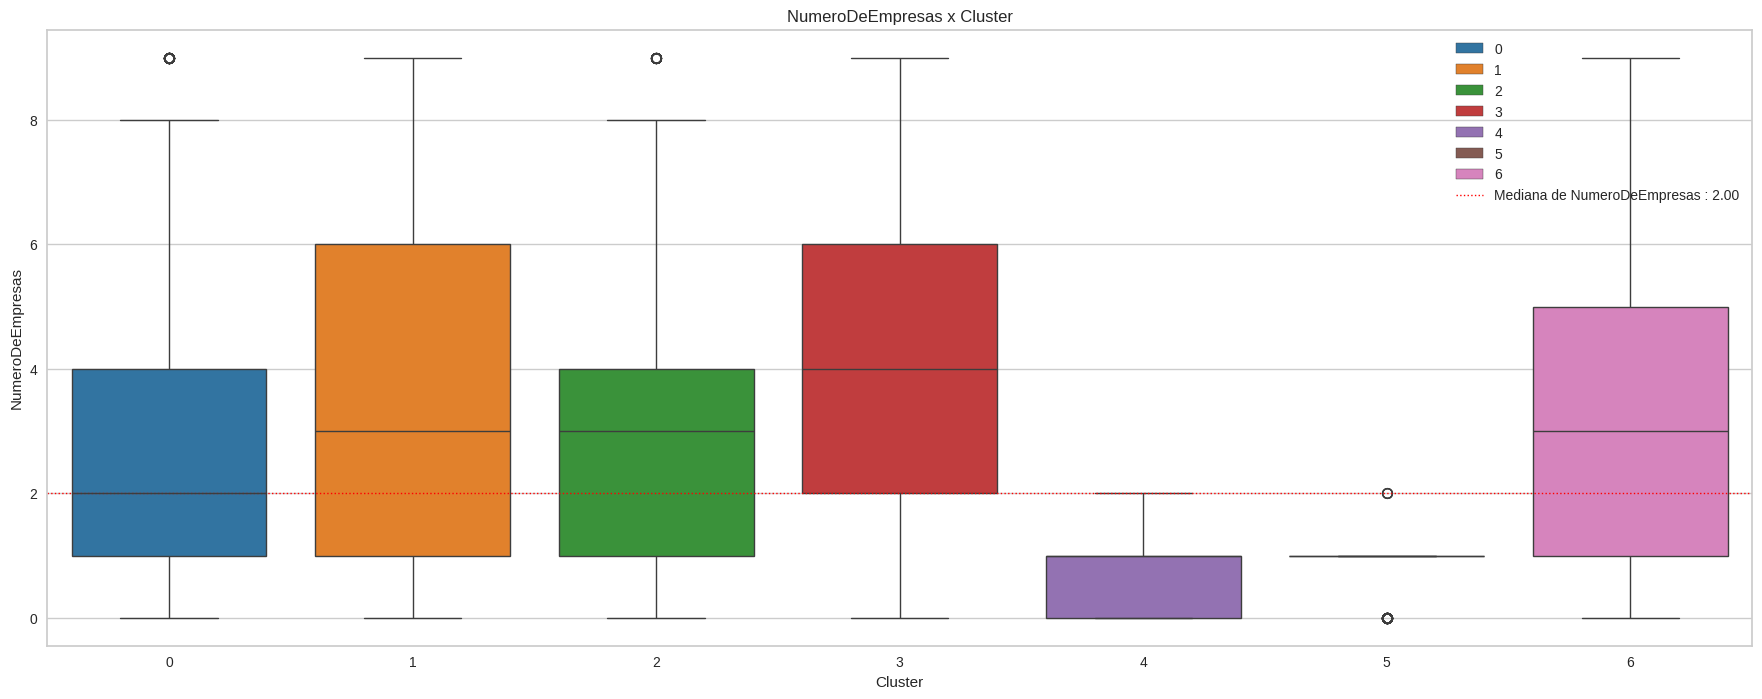

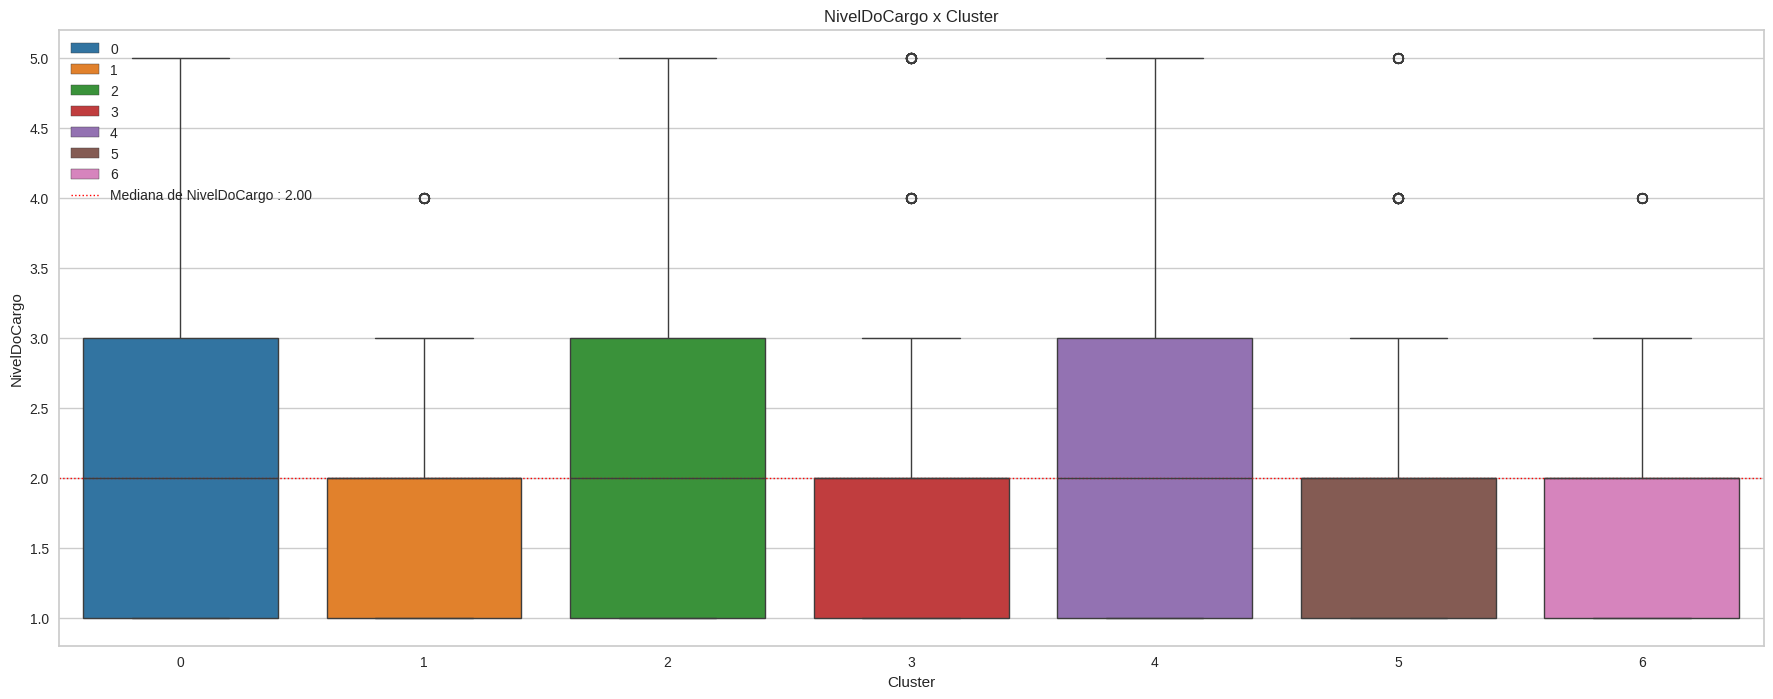

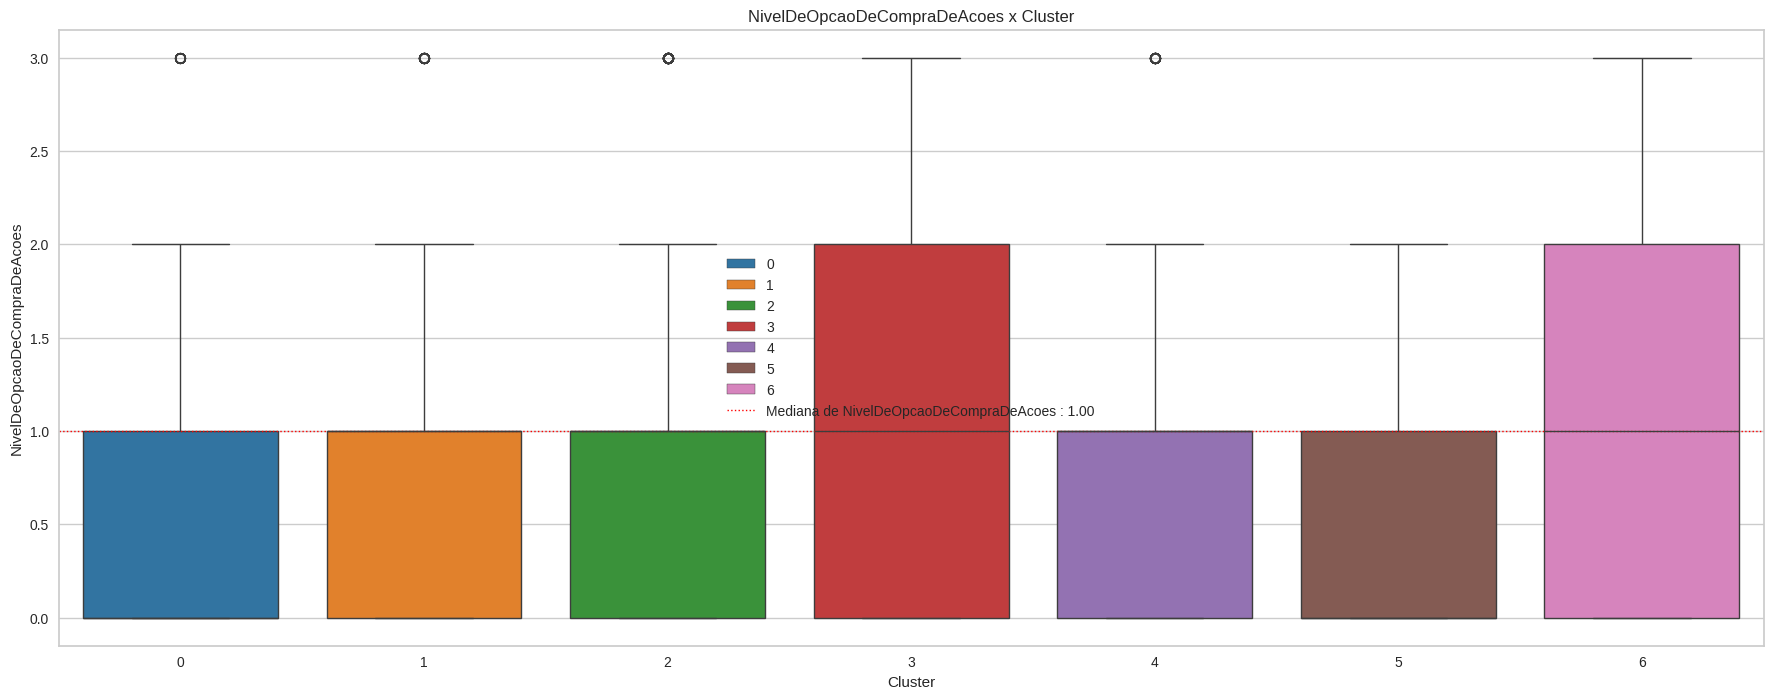

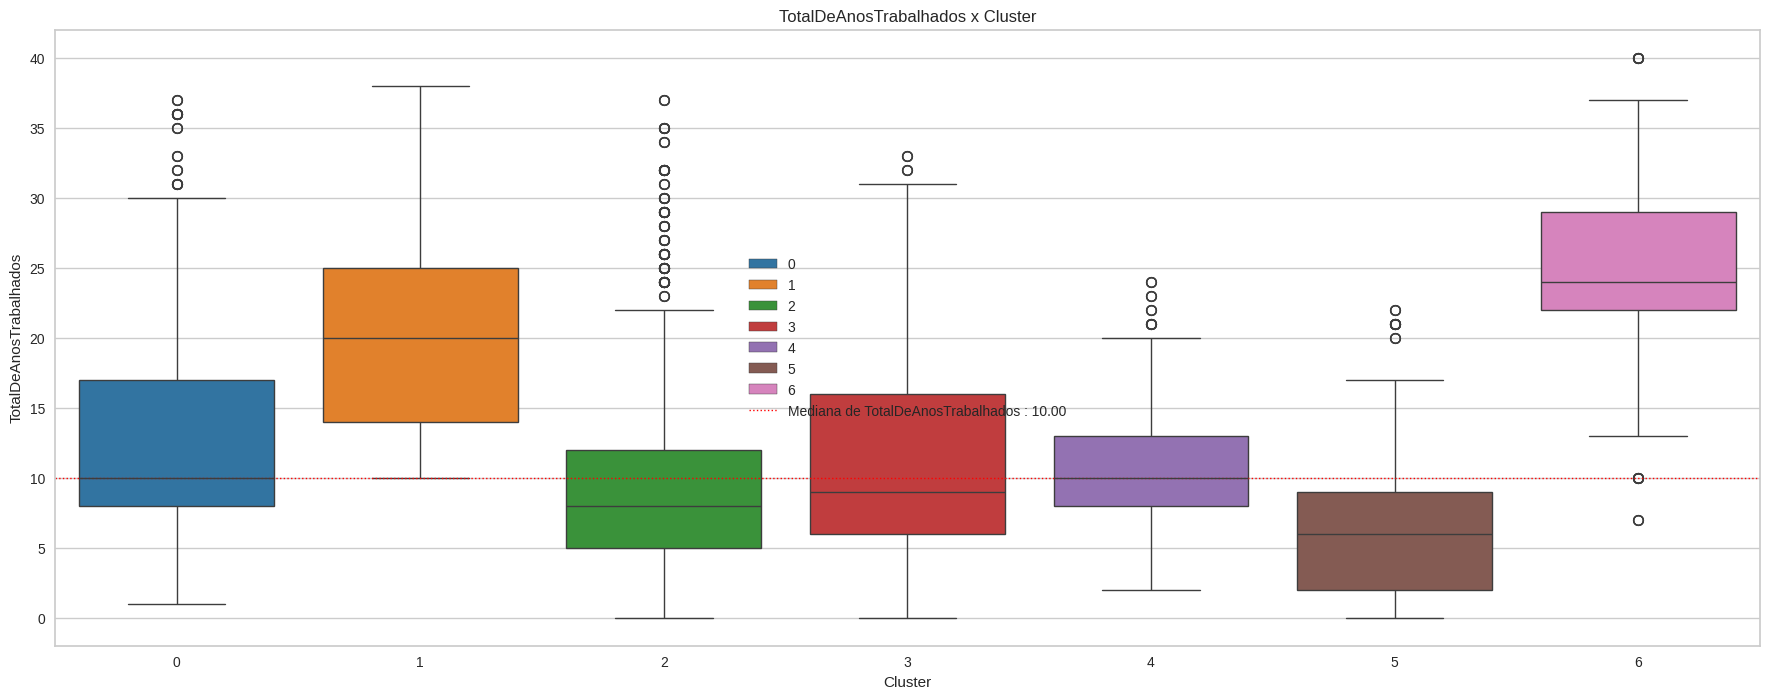

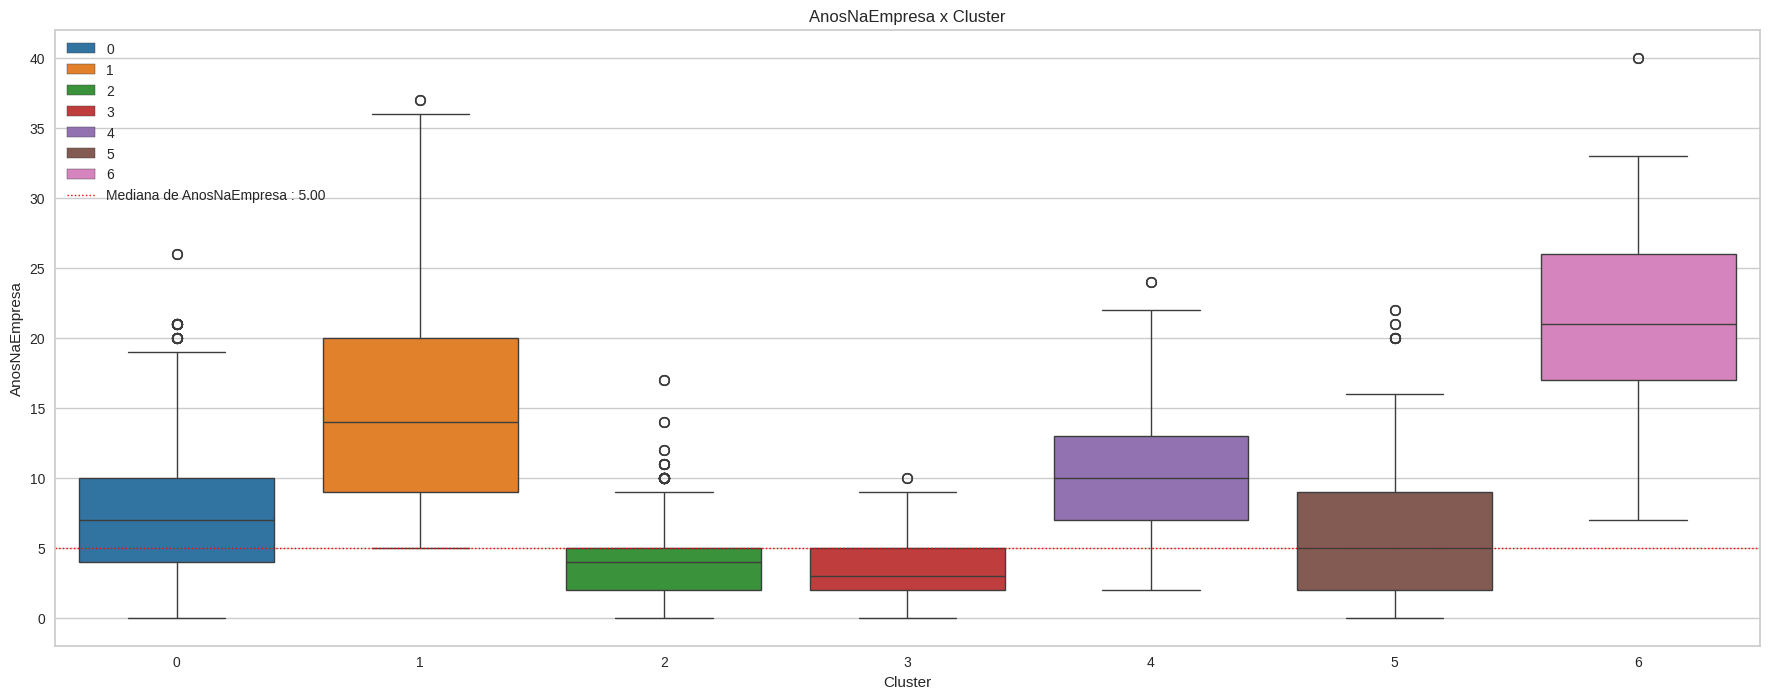

In [32]:
vars_numericas = list(set(df_publico.columns) - set(vars_categoricas) - set(['ContagemDeEmpregados','Rotatividade','MaiorDe18','TARGET','Cluster','IDDoEmpregado']))
for var in vars_numericas:
  plt.figure(figsize=(22, 8))
  pl=sns.boxplot(x=df_publico["Cluster"], y=df_publico[var], palette= pal, hue=df_publico["Cluster"])

  mediana = df_publico[var].median()
  # Adicionando uma linha indicando a média da variável de rotatividade
  text = f'Mediana de {var} :'+' {:.2f}'.format(mediana)
  plt.axhline(mediana, color='red', linestyle='dotted', linewidth=1, label=text)

  pl.set_title(f"{var} x Cluster")
  plt.legend()
  plt.show()

Insights gerados:
* Distância de casa:
  * Os funcionários pertencentes aos clusters 0 precisam percorrer a maior distância até o trabalho. Enquanto os colaboradores contidos nos clusters 2 e 6 necessitam percorrer a menor distância até o trabalho.
  * Dentre os clusters com maior taxa de rotatividade (3 e 5) o cluster 3 apresenta a maior distância da casa do funcionário até o trabalho.
* Horas de Trabalho:
  * Aparentemente não há diferença significativa entre a quantidade de horas trabalhadas por cluster.
* Nível de opção de compra de ações:
  * Os clusters 0 e 5 apresentam o mesmo comportamento tendo concentração entre 0 e 1 e mediana igual a 0;
  * Os clusters 1, 2 e 4 apresentam o mesmo comportamento tendo concentração entre 0 e 1 e mediana igual a 1;
  * Os clusters 3 e 6 apresentam o mesmo comportamento tendo concentração entre 0 e 2 e mediana igual a 1;
* Renda Mensal:
  * Os funcionários contidos no cluster 3 apresentam a menor renda mensal sendo relativamente próxima ao comportamento apresentado no cluster 6;
  * Os colaboradores que fazem parte dos clusters 4 e 5 são os mais bem remunerados na empresa.
* Nível do Cargo:
  * Todos os clusters apresentam mediana igual a 2;
  * Os clusters 0, 2 e 4 contem funcionários que estão concentrados principalmente nos níveis 1 a 3;
  * Os funcionários contidos nos clusters 1, 3, 5 e 6 estão concentrados nos níveis 1 e 2.
* Aumento Percentual Salarial:
  * Os colaboradores pertences aos clusters com maior taxa de rotatividade são os que mais receberam aumento percentual no salário.
* Anos desde a última promoção:
  * Os clusters 2, 3 e 5 apresentam a menor quantidade de anos desde a última promoção. Indicando que os funcionários pertencentes a estes clusters foram promovidos recentemente;
  * O cluster 6 se destaca em possuir a maior quantidade de anos desde a última promoção.
* Treinamentos no último ano:
  * Todos os clusters apresentam o mesmo intervalo interquartil apresentando mediana igual a 3 com exceção do cluster 4 que apresenta mediana igual a 2.
* Idade:
  * Os colaboradores de maior idade estão concentrados no cluster 6;
  * As medianas de idade dos funcionários pertencentes aos cluster 3 e 5 são 39 e 29 anos respectivamente;
  * Os funcionários mais novos estão concentrados no cluster 5.
* Total de anos trabalhados:
  * Os colaboradores com maior quantidade de anos trabalhados estão concentrados no cluster 6;
  * Os funcionários com menor quantidade de anos trabalhados estão concentrados no cluster 5;
  * As medianas de anos trabalhados para os funcionários contidos nos cluster 0 e 3 são próximas.
* Número de empresas (Número total de empresas pelas quais o funcionário passou):
  * O cluster 3 apresentou a maior mediana indicando que os funcionários que passaram pela maior quantidade de empresas tendem a estar concentrados neste cluster;
  * O cluster 0 (menor taxa de rotatividade) possui a menor mediana, significando que neste cluster se concentram colaboradores que passaram por uma menor quantidade de empresas;
  * O cluster com maior taxa de rotatividade apresentou mediana igual ao dobro do cluster com menor taxa de rotatividade.
* Anos com atual gestor:
  * Os clusters 2 e 3 concentram funcionários que tiveram a menor quantidade de anos com o atual gestor;
  * Os clusters 1 e 6 concentram funcionários que tiveram a maior quantidade de anos com o atual gestor;
  * A mediana da quantidade de anos com atual gestor é bem superior no cluster 0 do que no cluster 3.
* Anos na empresa:
  * Os funcionários com maior quantidade de anos na empresa estão concentrados no cluster 6;
  * Os colaboradores com menor quantidade de anos na empresa estão concentrados no cluster 3;

# Considerações Finais

Principais insights:
  * Os clusters com maior taxa de rotatividade são o 3 e 5;
  * As principais características do cluster 3 são:
    * 69,2% são do gênero masculino e 30,8% feminino;
    * Boa parte dos funcionários viajam com frequência;
    * Concentra o maior percentual com baixo nível de satisfação com o ambiente;
    * Concentra o menor percentual com nível muito alto de satisfação com o ambiente;
    * Concentra o maior percentual com alto nível de satisfação com o trabalho;
    * 67,4% dos funcionários tiveram nível de envolvimento no trabalho igual ou superior a 3;
    * Tem a maior concentração em percentual dos funcionários com nível de educação abaixo do superior;
    * 32,1% dos funcionários tem nível abaixo do superior ou no máximo ensino superior incompleto;
    * Os funcionários devem percorrer uma distância de casa ao trabalho acima que a mediana dos funcionários da empresa;
    * Estão concentrados em nível de compra de 0 a 2 em que 50% dos funcionários estão até o nível 1;
    * Concentra as menores rendas mensais;
    * Funcionários apresentam níveis de cargo predominantemente iguais a 1 e 2;
    * Concentra os funcionários que mais recebem aumento percentual no salário;
    * Funcionários tem poucos anos desde a última promoção;
    * 50% dos funcionários possuem até 39 anos;
    * 50% dos funcionários possuem até 9 anos trabalhados. Valor abaixo da mediana do total de anos trabalhados pelos funcionários da empresa;
    * 50% dos funcionários possuem passaram por até 4 empresas, sendo o dobro da mediana dos funcionários da empresa;
    * 50% dos funcionários possuem até 4 anos com atual gestor. Valor acima da mediana da quantidade de anos com atual gestor que os funcionários da empresa tem;
    * Concentra o maior percentual de funcionários com poucos anos de empresa.
  * As principais características do cluster 5 são:
    * 62,4% são do gênero masculino e 37,6% feminino;
    * 82,9% viajam a trabalho;
    * Concentra o maior percentual de solteiros;
    * Concentra o maior percentual de funcionários com nível médio de satisfação com o ambiente. Além disso, apresenta percentuais muito baixos de satisfação muito alta com o ambiente;
    * 63,1%  dos funcionários apresentam nível de satisfação com o ambiente igual a 3 ou superior;
    * 62,4% dos colaboradores apresentam nível de satisfação com o trabalho alto ou muito alto;
    * 67,9% dos funcionários tiveram nível de envolvimento no trabalho igual ou superior a 3;
    * Possui percentualmente a maior concentração de funcionários com máxima nota na avaliação de desempenho;
    * 28,6% dos funcionários tem nível abaixo do superior ou no máximo ensino superior incompleto;
    * Os funcionários devem percorrer uma distância de casa ao trabalho acima que a mediana dos funcionários da empresa;
    * Está concentrado em nível de compra de 0 a 1 em que 50% dos funcionários estão no nível 0;
    * Os funcionários estão entre os mais bem remunerados na empresa;
    * Funcionários apresentam níveis de cargo predominantemente iguais a 1 e 2;
    * Concentra os funcionários que mais recebem aumento percentual no salário;
    * Funcionários tem poucos anos desde a última promoção;
    * 50% dos funcionários possuem até 29 anos;
    * 50% dos funcionários possuem até 6 anos trabalhados. Valor abaixo da mediana do total de anos trabalhados pelos funcionários da empresa;
    * 50% dos funcionários possuem passaram por apenas 1 empresa, sendo a metade da mediana dos funcionários da empresa;
    * 50% dos funcionários possuem até 1 ano com atual gestor. Valor abaixo da mediana da quantidade de anos com atual gestor que os funcionários da empresa tem;
    * A quantidade de anos que os funcionários tem na empresa está relativamente próxima do padrão geral na empresa.

# Acionáveis

* Cluster 3:
  * Oferecer programas de desenvolvimento profissional e educação continuada para os funcionários com níveis educacionais abaixo do superior. Isso pode incluir subsídios para educação, treinamentos internos ou parcerias com instituições de ensino para oferecer cursos relevantes para suas funções;
  * Implementar programas de retenção de funcionários, como bonificações por tempo de serviço ou reconhecimento público de realizações individuais. Isso pode ajudar a aumentar a lealdade dos funcionários e reduzir a rotatividade;
  * Realizar uma pesquisa detalhada para identificar os principais motivos de insatisfação com o ambiente de trabalho. Com base nos resultados, implementar medidas para melhorar esses aspectos, como melhorias na infraestrutura do local de trabalho, programas de bem-estar ou iniciativas para promover um ambiente mais colaborativo e inclusivo.
* Cluster 5:
  * Reconhecer e recompensar os funcionários que recebem as melhores avaliações de desempenho e que demonstram alto nível de engajamento e satisfação no trabalho. Isso pode ser feito por meio de programas de reconhecimento, prêmios ou oportunidades de promoção;
  * Realizar pesquisas regulares de satisfação e envolvimento para monitorar o nível de satisfação e identificar áreas de melhoria contínua. Usar os resultados dessas pesquisas para orientar iniciativas futuras e garantir que as necessidades dos funcionários sejam atendidas;
  * Implementar programas de suporte ao bem-estar que ajudem os funcionários a lidar com os desafios associados às viagens frequentes, como programas de saúde mental, acesso a recursos de bem-estar durante as viagens e programas de apoio à família;
  * Oferecer opções de trabalho flexíveis para os funcionários, especialmente para aqueles que viajam com frequência. Isso pode incluir horários flexíveis, dias de trabalho remoto e políticas de licença mais abrangentes;
  * Investir em comodidades e recursos para tornar as viagens a trabalho mais confortáveis e eficientes para os funcionários, como apoio logístico, acesso a espaços de trabalho remotos e programas de recompensa por milhas de viagem;
  * Implementar programas de desenvolvimento de liderança e mentoria para os funcionários, especialmente aqueles com alto potencial que apresentam altos níveis de satisfação no trabalho e envolvimento. Isso pode ajudá-los a avançar em suas carreiras e aumentar a retenção de talentos.

In [55]:
df_aux = df_publico[df_publico.Cluster == 5]

df_publico['AnosNaEmpresa'].describe()

count    4410.000000
mean        7.008163
std         6.125135
min         0.000000
25%         3.000000
50%         5.000000
75%         9.000000
max        40.000000
Name: AnosNaEmpresa, dtype: float64

In [34]:
df_aux['AnosNaEmpresa'].describe()

count    684.000000
mean       5.619883
std        4.362285
min        0.000000
25%        2.000000
50%        5.000000
75%        9.000000
max       22.000000
Name: AnosNaEmpresa, dtype: float64

In [35]:
df_publico.groupby('Cluster')['AnosNaEmpresa'].median()

Cluster
0     7.0
1    14.0
2     4.0
3     3.0
4    10.0
5     5.0
6    21.0
Name: AnosNaEmpresa, dtype: float64